In [1]:
import sys
import os

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from AssignmentI.helper import (
    running_average_forecast,
    lag_forecast,
    exp_smoothing_forecast,
    metrics,
    running_trend_forecast,
    random_walk_plus_drift_forecast,
    estimate_alpha_exponential_smoothing,
    holt_fitted_forecast_series
)

In [2]:
import AssignmentI.helper as helper

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm
from scipy import stats

## AR(1)

In [4]:
def _ols_intercept_slope(x, z):
    """
    Closed-form OLS for z = mu + phi x + e.
    Returns (mu_hat, phi_hat).
    """
    x = np.asarray(x, dtype=float)
    z = np.asarray(z, dtype=float)

    x_mean = float(np.mean(x))
    z_mean = float(np.mean(z))

    sxx = float(np.sum((x - x_mean) ** 2))
    if sxx == 0.0:
        phi_hat = 0.0
    else:
        sxz = float(np.sum((x - x_mean) * (z - z_mean)))
        phi_hat = sxz / sxx

    mu_hat = z_mean - phi_hat * x_mean
    return float(mu_hat), float(phi_hat)


def ar1_forecast(y):
    """
    Expanding-window AR(1) one-step-ahead forecasts.
    For each t >= 2 (0-based), fit AR(1) on y[0..t-1] and forecast y[t].
    """
    y = np.asarray(y, dtype=float)
    T = len(y)
    f = np.full(T, np.nan, dtype=float)

    for t in range(2, T):
        y_past = y[:t]
        y_dep = y_past[1:]
        y_lag = y_past[:-1]

        mu, phi = _ols_intercept_slope(y_lag, y_dep)
        f[t] = mu + phi * y_past[-1]

    return f


def ar1_forecast_debug(y, rounding=2):
    """
    Debug version of expanding-window AR(1) forecasts.
    Prints parameter estimates and one-step-ahead forecasts at each t.
    """
    y = np.asarray(y, dtype=float)
    T = len(y)
    f = np.full(T, np.nan, dtype=float)

    for t in range(2, T):
        y_past = y[:t]
        y_dep = y_past[1:]
        y_lag = y_past[:-1]

        mu, phi = _ols_intercept_slope(y_lag, y_dep)

        mu_r = round(mu, rounding)
        phi_r = round(phi, rounding)
        f[t] = round(mu_r + phi_r * y_past[-1], rounding)

        print(f"t = {t}")
        print(f"last observed y[t-1] = {y_past[-1]}")
        print(f"mu_hat = {mu_r}")
        print(f"phi_hat = {phi_r}")
        print(f"forecast y[t] = {f[t]}")
        print("-" * 40)

    return f

## MA(1)

In [5]:
def ma1_objective(params, y, criterion="MSE"):
    mu, theta = params
    eps = 0.0
    errs = []

    for val in y:
        # One-step-ahead error calculation
        err = val - (mu + theta * eps)
        errs.append(err)
        eps = err

    errs = np.asarray(errs, dtype=float)

    # Minimize based on the chosen statistic
    if criterion == "SSE":
        return float(np.sum(errs**2))
    elif criterion == "MSE":
        return float(np.mean(errs**2))
    elif criterion == "MAE":
        return float(np.mean(np.abs(errs)))
    else:
        raise ValueError("criterion must be 'SSE', 'MSE', or 'MAE'")

def ma1_forecast(y, criterion="MSE"):
    y = np.asarray(y, dtype=float)
    f = np.full(len(y), np.nan)

    # Define Grid Ranges
    # theta must be between -1 and 1 for invertibility
    theta_grid = np.linspace(-0.99, 0.99, 100) 
    
    for t in range(3, len(y)):
        y_past = y[:t]
        y_mean = np.mean(y_past)
        
        # We test mu values around the local mean
        mu_grid = np.linspace(y_mean * 0.8, y_mean * 1.2, 11)
        
        best_score = float('inf')
        best_params = (y_mean, 0.1)

        # Grid Search Loop
        for mu in mu_grid:
            for theta in theta_grid:
                score = ma1_objective([mu, theta], y_past, criterion)
                if score < best_score:
                    best_score = score
                    best_params = (mu, theta)

        mu_hat, theta_hat = best_params
        
        # Calculate the last error (epsilon) using best parameters
        eps = 0.0
        for val in y_past:
            eps = val - (mu_hat + theta_hat * eps)

        f[t] = mu_hat + theta_hat * eps

    return f

## ARMA(1, 1)

In [6]:
# ARMA(1,1) objective: minimize an in-sample one-step-ahead forecast error statistic (default: SSE)
def arma11_objective(params, y, criterion="MSE"):
    c, phi, theta = params
    eps = 0.0
    errs = []

    for t in range(1, len(y)):
        f_t = c + phi * y[t - 1] + theta * eps
        err = y[t] - f_t
        errs.append(err)
        eps = err

    errs = np.asarray(errs, dtype=float)

    if criterion == "SSE":
        return float(np.sum(errs**2))
    elif criterion == "MSE":
        return float(np.mean(errs**2))
    elif criterion == "MAE":
        return float(np.mean(np.abs(errs)))
    else:
        raise ValueError("criterion must be 'SSE', 'MSE', or 'MAE'")

def arma11_forecast(y, criterion="MSE"):
    y = np.asarray(y, dtype=float)
    f = np.full(len(y), np.nan)

    # Define Grids
    phi_grid = np.linspace(-0.99, 0.99, 100)   # Autoregressive term
    theta_grid = np.linspace(-0.99, 0.99, 100) # Moving average term

    for t in range(3, len(y)):
        y_past = y[:t]
        y_mean = np.mean(y_past)
        
        # c is roughly y_mean * (1 - phi)
        # We search a small range around this logical starting point
        best_score = float('inf')
        best_params = (0.0, 0.5, 0.1)

        for phi in phi_grid:
            # Dynamically center the constant 'c' based on the current phi
            c_approx = y_mean * (1 - phi)
            c_grid = [c_approx * 0.9, c_approx, c_approx * 1.1]
            
            for c in c_grid:
                for theta in theta_grid:
                    score = arma11_objective([c, phi, theta], y_past, criterion)
                    if score < best_score:
                        best_score = score
                        best_params = (c, phi, theta)

        c_hat, phi_hat, theta_hat = best_params

        # Calculate final error (eps) with best parameters
        eps = 0.0
        for i in range(1, len(y_past)):
            f_i = c_hat + phi_hat * y_past[i - 1] + theta_hat * eps
            eps = y_past[i] - f_i

        f[t] = c_hat + phi_hat * y_past[-1] + theta_hat * eps

    return f

## Mincer–Zarnowitz and Diebold–Mariano test

In [ ]:
def mz_test(y_true, y_pred):

    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)

    X = sm.add_constant(y_pred, has_constant="add")
    model = sm.OLS(y_true, X).fit()

    # If model did not estimate two parameters, skip joint test
    if len(model.params) != 2:
        return {
            "alpha_hat": np.nan,
            "beta_hat": np.nan,
            "F_stat": np.nan,
            "p_value": np.nan,
            "note": "Regression not identified (forecast constant)"
        }

    R = np.array([[1., 0.],
                  [0., 1.]])
    r = np.array([0., 1.])

    ftest = model.f_test((R, r))

    return {
        "alpha_hat": model.params[0],
        "beta_hat": model.params[1],
        "F_stat": float(ftest.fvalue),
        "p_value": float(ftest.pvalue),
    }


# ---------------------------------
# 2) Diebold–Mariano (DM) test
# ---------------------------------
import numpy as np
from scipy import stats

def dm_test(y_true, y_pred_1, y_pred_2, loss="mse", h=1, nw_lags=None, use_nw=False):
    """
    Diebold–Mariano test comparing predictive accuracy of two models.
    
    If use_nw=False: Uses standard OLS variance and t-distribution p-values.
    If use_nw=True: Uses Newey-West (HAC) variance and normal distribution p-values.
    """
    y_true = np.asarray(y_true).astype(float)
    y_pred_1 = np.asarray(y_pred_1).astype(float)
    y_pred_2 = np.asarray(y_pred_2).astype(float)

    # Calculate residuals
    e1 = y_true - y_pred_1
    e2 = y_true - y_pred_2

    # Define loss series
    if loss.lower() == "mse":
        L1, L2 = e1**2, e2**2
    elif loss.lower() == "mae":
        L1, L2 = np.abs(e1), np.abs(e2)
    else:
        raise ValueError("loss must be 'mse' or 'mae'")

    # Loss differential d_t
    d = L1 - L2
    d = d[~np.isnan(d)]
    T = len(d)
    d_bar = np.mean(d)

    if not use_nw:
        # --- Logic for use_nw = False ---
        # Using sample standard deviation / sqrt(T)
        se = np.std(d, ddof=1) / np.sqrt(T)
        dm_stat = d_bar / se
        # p-value from t-distribution
        p_value = 2 * (1 - stats.t.cdf(np.abs(dm_stat), df=T - 1))
        nw_lags_used = 0
    else:
        # --- Logic for use_nw = True ---
        if nw_lags is None:
            nw_lags_used = max(h - 1, 0)
        else:
            nw_lags_used = nw_lags

        d_centered = d - d_bar
        gamma0 = np.sum(d_centered**2) / T
        hac_sum = gamma0

        for k in range(1, nw_lags_used + 1):
            wk = 1.0 - k / (nw_lags_used + 1.0)
            cov_k = np.sum(d_centered[k:] * d_centered[:-k]) / T
            hac_sum += 2.0 * wk * cov_k

        var_dbar = hac_sum / T
        if var_dbar <= 0:
            raise RuntimeError("Non-positive HAC variance encountered.")
        
        dm_stat = d_bar / np.sqrt(var_dbar)
        # p-value from normal distribution (standard for HAC-based DM)
        p_value = 2.0 * (1.0 - stats.norm.cdf(np.abs(dm_stat)))

    return {
        "dm_stat": float(dm_stat),
        "p_value": float(p_value),
        "mean_loss_diff": float(d_bar),
        "loss": loss.lower(),
        "h": int(h),
        "nw_lags": int(nw_lags_used),
        "use_nw": use_nw,
        "T": int(T)
    }

### Gasoline Sales 1
This section evaluates the performance of AR(1), MA(1), and ARMA(1,1) models against the benchmark methods from Assignment I using the GasolineSales1 dataset.

In [8]:
# Load Gasoline Sales 1
df_gas1 = pd.read_excel('GasolineSales1.xlsx')
y_gas1 = df_gas1['Gasoline'].values

# Compute Forecasts
f_ra = running_average_forecast(y_gas1)
f_rw = lag_forecast(y_gas1)
f_ar1 = ar1_forecast(y_gas1)
f_ma1 = ma1_forecast(y_gas1)
f_arma11 = arma11_forecast(y_gas1)

f_es02 = exp_smoothing_forecast(y_gas1, alpha=0.2)
f_es08 = exp_smoothing_forecast(y_gas1, alpha=0.8)

best_alpha, yhat_best, u_best = estimate_alpha_exponential_smoothing(y_gas1, criterion="MSE")
f_esEst = yhat_best

# Expert forecast
f_expert = np.full(len(y_gas1), 19.0, dtype=float)

methods = {
    "Expert (19)": f_expert,
    "Running Avg": f_ra,
    "Random Walk": f_rw,
    "ExpSmo (0.2)": f_es02,
    "ExpSmo (0.8)": f_es08,
    "ExpSmo (Est)": f_esEst,
    "AR(1)": f_ar1,
    "MA(1)": f_ma1,
    "ARMA(1,1)": f_arma11,
}

k = 6

results_gas1 = {
    name: metrics(
        y_gas1[-k:],
        np.asarray(f, dtype=float)[-k:]
    )
    for name, f in methods.items()
}

df_results_gas1 = pd.DataFrame(results_gas1, index=['ME', 'MAE', 'MAPE', 'MSE']).T
df_results_gas1 = df_results_gas1.sort_values(by="MSE")
display(df_results_gas1)

,ME,MAE,MAPE,MSE
MA(1),0.154045,1.821352,9.966602,4.459045
AR(1),-0.151584,1.890674,10.529391,5.288395
Expert (19),0.500000,2.166667,11.582492,6.166667
"ARMA(1,1)",0.449799,2.288693,11.876697,6.306003
Running Avg,0.353968,2.201587,11.881433,6.685094
ExpSmo (0.2),0.770396,2.423688,12.850786,7.952316
ExpSmo (Est),0.667314,2.435914,12.991933,8.241439
ExpSmo (0.8),0.883354,3.489039,18.291466,15.332792
Random Walk,1.000000,4.000000,20.740741,19.000000


In [9]:
# ===============================
# Gasoline Sales 1: MZ tests
# ===============================
mz_results_gas1 = {}

y_oos_gas1 = y_gas1[-k:]

for name, f in methods.items():
    f_oos_gas1 = np.asarray(f, dtype=float)[-k:]
    r = mz_test(y_oos_gas1, f_oos_gas1)

    mz_results_gas1[name] = {
        "alpha_hat": r["alpha_hat"],
        "beta_hat": r["beta_hat"],
        "F_stat(H0:a=0,b=1)": r["F_stat"],
        "p_value": r["p_value"],
    }

df_mz_gas1 = pd.DataFrame(mz_results_gas1).T.sort_values("p_value")
display(df_mz_gas1)


# ===============================
# Gasoline Sales 1: DM tests
# ===============================

# Select best model based on MSE (Gas 1)
best_name_gas1 = df_results_gas1.index[0]
best_f_oos_gas1 = np.asarray(methods[best_name_gas1], dtype=float)[-k:]

dm_results_gas1 = {}

for name, f in methods.items():
    if name == best_name_gas1:
        continue

    f_oos_gas1 = np.asarray(f, dtype=float)[-k:]

    r = dm_test(
        y_true=y_oos_gas1,
        y_pred_1=f_oos_gas1,
        y_pred_2=best_f_oos_gas1,
        loss="mse",
        h=1,
        nw_lags=0
    )

    dm_results_gas1[name] = {
        "dm_stat (L1-Lbest)": r["dm_stat"],
        "p_value": r["p_value"],
        "mean_loss_diff": r["mean_loss_diff"],
    }

df_dm_gas1 = pd.DataFrame(dm_results_gas1).T.sort_values("p_value")

print("Gas1 baseline (lowest MSE):", best_name_gas1)
display(df_dm_gas1)

c:\Users\georg\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '


,alpha_hat,beta_hat,"F_stat(H0:a=0,b=1)",p_value
Random Walk,29.140845,-0.521127,6.816993,0.051454
ExpSmo (0.8),33.153022,-0.733377,5.602259,0.069211
Running Avg,235.768762,-11.295749,3.483421,0.133032
ExpSmo (Est),83.566377,-3.401871,3.266982,0.144190
ExpSmo (0.2),95.109765,-4.036912,2.781087,0.174987
MA(1),-45.407000,3.355068,0.976214,0.451577
Expert (19),0.053867,1.023481,0.211268,0.665069
"ARMA(1,1)",11.712348,0.408796,0.195176,0.830083
AR(1),-5.241303,1.258998,0.019767,0.980522


Gas1 baseline (lowest MSE): MA(1)


,dm_stat (L1-Lbest),p_value,mean_loss_diff
ExpSmo (0.8),2.234635,0.075723,10.873747
ExpSmo (Est),2.195141,0.079579,3.782395
Random Walk,2.181933,0.080916,14.540955
ExpSmo (0.2),2.130404,0.086360,3.493272
Running Avg,1.935201,0.110750,2.226050
Expert (19),1.645280,0.160831,1.707622
"ARMA(1,1)",0.878641,0.419809,1.846958
AR(1),0.841331,0.438536,0.829351


### Gasoline Sales 2
This section evaluates the performance of AR(1), MA(1), and ARMA(1,1) models against the benchmark methods from Assignment I using the GasolineSales2 dataset.

In [10]:
# Load Gasoline Sales 2
df_gas2 = pd.read_excel('GasolineSales2.xlsx')
y_gas2 = df_gas2['Gasoline'].values

# Compute Forecasts
f2_ra = running_average_forecast(y_gas2)
f2_rw = lag_forecast(y_gas2)
f2_ar1 = ar1_forecast(y_gas2)
f2_ma1 = ma1_forecast(y_gas2)
f2_arma11 = arma11_forecast(y_gas2)

f2_es02 = exp_smoothing_forecast(y_gas2, alpha=0.2)
f2_es08 = exp_smoothing_forecast(y_gas2, alpha=0.8)

best_alpha, yhat_best, u_best = estimate_alpha_exponential_smoothing(y_gas2, criterion="MSE")
f2_esEst = yhat_best

f2_expert = np.full(len(y_gas2), 19.0, dtype=float)

methods2 = {
    "Expert (19)": f2_expert,
    "Running Avg": f2_ra,
    "Random Walk": f2_rw,
    "ExpSmo (0.2)": f2_es02,
    "ExpSmo (0.8)": f2_es08,
    "ExpSmo (Est)": f2_esEst,
    "AR(1)": f2_ar1,
    "MA(1)": f2_ma1,
    "ARMA(1,1)": f2_arma11
}

k = 16

results_gas2 = {
    name: metrics(y_gas2[-k:], np.asarray(f, dtype=float)[-k:])
    for name, f in methods2.items()
}

df_results_gas2 = pd.DataFrame(results_gas2, index=['ME', 'MAE', 'MAPE', 'MSE']).T
df_results_gas2 = df_results_gas2.sort_values(by="MSE")
display(df_results_gas2)

,ME,MAE,MAPE,MSE
ExpSmo (0.8),1.284398,3.435008,13.634007,17.819096
Random Walk,1.062500,3.687500,14.765408,18.062500
ExpSmo (Est),1.696578,3.688102,13.618557,25.085618
AR(1),2.014587,3.551749,12.814104,27.141130
"ARMA(1,1)",2.888970,4.125185,14.651103,30.304554
ExpSmo (0.2),3.776038,4.396023,15.629081,32.291120
Running Avg,5.878591,6.571448,22.503572,59.632742
MA(1),5.018917,5.644158,19.025012,68.803722
Expert (19),8.000000,8.625000,28.994710,102.375000


In [11]:
# ===============================
# Gasoline Sales 2: MZ tests
# ===============================
mz_results_gas2 = {}

y_oos_gas2 = y_gas2[-k:]

for name, f in methods2.items():
    f_oos_gas2 = np.asarray(f, dtype=float)[-k:]
    r = mz_test(y_oos_gas2, f_oos_gas2)

    mz_results_gas2[name] = {
        "alpha_hat": r["alpha_hat"],
        "beta_hat": r["beta_hat"],
        "F_stat(H0:a=0,b=1)": r["F_stat"],
        "p_value": r["p_value"],
    }

df_mz_gas2 = pd.DataFrame(mz_results_gas2).T.sort_values("p_value")
display(df_mz_gas2)


# ===============================
# Gasoline Sales 2: DM tests
# ===============================

# Select best model based on MSE (Gas 2)
best_name_gas2 = df_results_gas2.index[0]
best_f_oos_gas2 = np.asarray(methods2[best_name_gas2], dtype=float)[-k]


best_f_oos_gas2 = np.asarray(methods2[best_name_gas2], dtype=float)[-k:]
y_oos_gas2 = y_gas2[-k:]

dm_results_gas2 = {}

for name, f in methods2.items():
    if name == best_name_gas2:
        continue

    f_oos_gas2 = np.asarray(f, dtype=float)[-k:]

    r = dm_test(
        y_true=y_oos_gas2,
        y_pred_1=f_oos_gas2,
        y_pred_2=best_f_oos_gas2,
        loss="mse",
        h=1,
        nw_lags=0
    )

    dm_results_gas2[name] = {
        "dm_stat (L1-Lbest)": r["dm_stat"],
        "p_value": r["p_value"],
        "mean_loss_diff": r["mean_loss_diff"],
    }

df_dm_gas2 = pd.DataFrame(dm_results_gas2).T.sort_values("p_value")

print("Gas2 baseline (lowest MSE):", best_name_gas2)
display(df_dm_gas2)

c:\Users\georg\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '


,alpha_hat,beta_hat,"F_stat(H0:a=0,b=1)",p_value
Expert (19),0.074586,1.417127,25.016287,0.000158
Running Avg,-18.856133,2.171074,14.278563,0.000417
MA(1),18.390205,0.391691,6.894014,0.008239
ExpSmo (0.2),2.727823,1.045135,5.561394,0.016689
"ARMA(1,1)",7.492422,0.809073,3.106193,0.076484
ExpSmo (Est),9.008708,0.711022,2.238088,0.143421
AR(1),8.157005,0.754160,1.934573,0.181205
Random Walk,7.497476,0.751905,1.833102,0.196288
ExpSmo (0.8),6.790835,0.785872,1.668898,0.223841


Gas2 baseline (lowest MSE): ExpSmo (0.8)


,dm_stat (L1-Lbest),p_value,mean_loss_diff
Expert (19),3.824655,0.001658,84.555904
Running Avg,3.043602,0.008210,41.813646
ExpSmo (0.2),1.539660,0.144470,14.472024
"ARMA(1,1)",1.527940,0.147337,12.485458
MA(1),1.344732,0.198694,50.984626
AR(1),1.004020,0.331291,9.322034
ExpSmo (Est),0.982604,0.341387,7.266522
Random Walk,0.113379,0.911234,0.243404


### Bicycle Sales
Bicycle sales comparison including trend-based models.

In [12]:
# Load Bicycle Sales
df_bike = pd.read_excel('BicycleSales.xlsx')
y_bike = df_bike['Bicycle'].values

# Compute Forecasts
f_b_ra = running_average_forecast(y_bike)
f_b_rt, _, _ = running_trend_forecast(y_bike)
f_b_rw = lag_forecast(y_bike)
_, f_b_rws, _ = random_walk_plus_drift_forecast(y_bike)

f_b_es02 = exp_smoothing_forecast(y_bike, alpha=0.2)
f_b_es08 = exp_smoothing_forecast(y_bike, alpha=0.8)

best_alpha, yhat_best, u_best = estimate_alpha_exponential_smoothing(y_bike, criterion="MSE")
f_b_esEst = yhat_best

f_b_ar1 = ar1_forecast(y_bike)
f_b_ma1 = ma1_forecast(y_bike)
f_b_arma11 = arma11_forecast(y_bike)

methods_bike = {
    "Running Avg": f_b_ra,
    "Running Trend": f_b_rt,
    "Random Walk": f_b_rw,
    "RW + Shift": f_b_rws,
    "ExpSmo (0.2)": f_b_es02,
    "ExpSmo (0.8)": f_b_es08,
    "ExpSmo (Est)": f_b_esEst,
    "AR(1)": f_b_ar1,
    "MA(1)": f_b_ma1,
    "ARMA(1,1)": f_b_arma11
}

k = 6

results_bike = {
    name: metrics(y_bike[-k:], np.asarray(f, dtype=float)[-k:])
    for name, f in methods_bike.items()
}

df_results_bike = pd.DataFrame(results_bike, index=['ME', 'MAE', 'MAPE', 'MSE']).T
df_results_bike = df_results_bike.sort_values(by="MSE")
print("Bicycle Sales Performance Comparison (last 6 forecasts):")
display(df_results_bike)

Bicycle Sales Performance Comparison (last 6 forecasts):


,ME,MAE,MAPE,MSE
Running Trend,0.784087,1.894802,6.440365,6.799347
RW + Shift,0.660476,2.562857,8.923502,6.902641
Random Walk,1.583333,2.550000,8.830247,7.541667
ExpSmo (0.8),1.746908,2.451513,8.415168,8.100885
ExpSmo (Est),1.907924,2.874591,9.789938,11.372407
MA(1),2.868877,3.041050,10.377880,13.370973
AR(1),1.779367,3.162095,10.544247,15.877879
ExpSmo (0.2),4.280957,4.280957,14.482959,22.372109
Running Avg,4.357956,4.357956,14.648279,23.256772
"ARMA(1,1)",4.032019,4.032019,13.504401,25.069779


In [13]:
# ===============================
# Bicycle Sales: MZ tests
# ===============================
mz_results_bike = {}

y_oos_bike = y_bike[-k:]

for name, f in methods_bike.items():
    f_oos_bike = np.asarray(f, dtype=float)[-k:]
    r = mz_test(y_oos_bike, f_oos_bike)

    mz_results_bike[name] = {
        "alpha_hat": r["alpha_hat"],
        "beta_hat": r["beta_hat"],
        "F_stat(H0:a=0,b=1)": r["F_stat"],
        "p_value": r["p_value"],
    }

df_mz_bike = pd.DataFrame(mz_results_bike).T.sort_values("p_value")
print("Bicycle Sales – MZ Test Results:")
display(df_mz_bike)


# ===============================
# Bicycle Sales: DM tests
# ===============================

# Select best model based on MSE (Bike)
best_name_bike = df_results_bike.index[0]
best_f_oos_bike = np.asarray(methods_bike[best_name_bike], dtype=float)[-k:]

dm_results_bike = {}

for name, f in methods_bike.items():
    if name == best_name_bike:
        continue

    f_oos_bike = np.asarray(f, dtype=float)[-k:]

    r = dm_test(
        y_true=y_oos_bike,
        y_pred_1=f_oos_bike,
        y_pred_2=best_f_oos_bike,
        loss="mse",
        h=1,
        nw_lags=0
    )

    dm_results_bike[name] = {
        "dm_stat (L1-Lbest)": r["dm_stat"],
        "p_value": r["p_value"],
        "mean_loss_diff": r["mean_loss_diff"],
    }

df_dm_bike = pd.DataFrame(dm_results_bike).T.sort_values("p_value")

print("Bicycle baseline (lowest MSE):", best_name_bike)
print("Bicycle Sales – DM Test Results:")
display(df_dm_bike)

Bicycle Sales – MZ Test Results:


,alpha_hat,beta_hat,"F_stat(H0:a=0,b=1)",p_value
Running Avg,-7.025877,1.466384,9.676335,0.029339
ExpSmo (0.2),3.855556,1.017373,9.062363,0.032686
"ARMA(1,1)",20.899817,0.318050,6.091561,0.061094
MA(1),13.169779,0.602248,4.886374,0.084349
AR(1),21.653230,0.263585,3.389790,0.137694
ExpSmo (Est),16.523619,0.455831,3.063619,0.156005
Random Walk,13.028839,0.578951,2.879023,0.168033
ExpSmo (0.8),12.768988,0.592073,2.631446,0.186478
RW + Shift,14.419187,0.510474,2.534731,0.194517
Running Trend,13.973390,0.528660,1.457832,0.334543


Bicycle baseline (lowest MSE): Running Trend
Bicycle Sales – DM Test Results:


,dm_stat (L1-Lbest),p_value,mean_loss_diff
Running Avg,2.696289,0.042974,16.457425
ExpSmo (0.2),2.595510,0.048512,15.572762
MA(1),2.439136,0.058716,6.571626
ExpSmo (Est),1.651386,0.159570,4.573060
AR(1),1.588816,0.172969,9.078532
"ARMA(1,1)",1.526763,0.187348,18.270432
ExpSmo (0.8),0.752389,0.485708,1.301538
Random Walk,0.314430,0.765891,0.742320
RW + Shift,0.029226,0.977815,0.103294


### Data Assignment 1: Nine Time Series Comparison

In [ ]:
# -----------------------------
# Data
# -----------------------------
df_1 = pd.read_excel("DataAssignment1.xlsx")

N = 50
y_list = [df_1.iloc[:, i].astype(float).to_numpy() for i in range(9)]
y_names = [f"y_{i+1}" for i in range(9)]

t_est_end = 30
t_fc_start = 30
t_fc_end = 40

t_fc2_start = 40
t_fc2_end   = 50

# -----------------------------
# Evaluation function 
# -----------------------------
def metrics(y_true, y_hat):
    u = y_true - y_hat
    return {
        "ME": np.mean(u),
        "MAE": np.mean(np.abs(u)),
        "MAPE": np.mean(100 * np.abs(u) / np.abs(y_true)),
        "MSE": np.mean(u**2),
    }

# -----------------------------
# Stores for Part 2 fixed params 
# -----------------------------
all_results = {}
exp_alpha_store = {}
exp_alpha_rolling_last_store = {}
holt_param_store = {}
holt_param_rolling_last_store = {}

# ============================================================
#  part 1 (t = 31..40) + store fixed params for part 2
# ============================================================
for idx, y in zip(y_names, y_list):
    y_est  = y[:t_est_end]
    y_eval = y[t_fc_start:t_fc_end]

    forecasts = {}

    # Average
    y_avg = np.mean(y_est)
    forecasts["Average"] = np.full_like(y_eval, y_avg)

    # Running average
    f_avg = helper.running_average_forecast(y)
    forecasts["Running Average"] = f_avg[t_fc_start:t_fc_end]

    # Running trend
    f_rt, _, _ = helper.running_trend_forecast(y)
    forecasts["Running Trend"] = f_rt[t_fc_start:t_fc_end]

    # Random walk
    f_rw = helper.lag_forecast(y)
    forecasts["Random Walk"] = f_rw[t_fc_start:t_fc_end]

    # Random walk + drift
    _, rw_drift, _ = helper.random_walk_plus_drift_forecast(y)
    forecasts["Random Walk + Drift"] = rw_drift[t_fc_start:t_fc_end]

    # Exponential smoothing (tuned on fixed window 31..40)
    alpha_candidates = np.linspace(1e-4, 1, 2000)
    best_alpha, best_mse = None, np.inf
    for alpha in alpha_candidates:
        f_es = helper.exp_smoothing_forecast(y[:t_fc_end], alpha)
        f_eval = f_es[t_fc_start:t_fc_end]
        mse = np.mean((y_eval - f_eval) ** 2)
        if mse < best_mse:
            best_alpha, best_mse = alpha, mse

    f_es = helper.exp_smoothing_forecast(y, best_alpha)[t_fc_start:t_fc_end]
    forecasts[f"Exponentional Smoothing (alpha = {best_alpha:.3f})"] = f_es
    exp_alpha_store[idx] = best_alpha

    # Exponential smoothing (retuned, rolling window size 10)
    f_es_rolling = np.full(10, np.nan)
    alpha_last = None
    for t in range(t_fc_start, t_fc_end):
        y_sub = y[:t]
        best_alpha, best_mse = None, np.inf

        for alpha in alpha_candidates:
            f_sub = helper.exp_smoothing_forecast(y_sub, alpha)
            f_window = f_sub[t-10:t]
            y_window = y[t-10:t]
            mse = np.mean((y_window - f_window) ** 2)
            if mse < best_mse:
                best_alpha, best_mse = alpha, mse

        alpha_last = best_alpha
        y_sub_t = y[:t+1]
        f_sub_best = helper.exp_smoothing_forecast(y_sub_t, best_alpha)
        f_es_rolling[t - t_fc_start] = f_sub_best[-1]

    forecasts["Exponentional Smoothing (retuned)"] = f_es_rolling
    exp_alpha_rolling_last_store[idx] = alpha_last

    # Holt-Winters (double exp smoothing) tuned on fixed window 31..40
    grid = np.linspace(1e-3, 1.0, 200)
    best_alpha, best_beta, best_mse = None, None, np.inf

    for alpha in grid:
        for beta in grid:
            f_hw = helper.holt_fitted_forecast_series(y[:t_fc_end], alpha, beta)
            f_eval = f_hw[t_fc_start:t_fc_end]
            mse = np.mean((y_eval - f_eval) ** 2)
            if mse < best_mse:
                best_alpha, best_beta, best_mse = alpha, beta, mse

    f_hw = helper.holt_fitted_forecast_series(y, best_alpha, best_beta)[t_fc_start:t_fc_end]
    forecasts[f"Holt-Winters (alpha = {best_alpha:.3f}, beta = {best_beta:.3f})"] = f_hw
    holt_param_store[idx] = (best_alpha, best_beta)

    # Holt-Winters retuned, rolling window size 10
    f_hw_rolling = np.full(10, np.nan)
    holt_param_last = None

    for t in range(t_fc_start, t_fc_end):
        best_alpha, best_beta, best_mse = None, None, np.inf
        y_sub = y[:t]

        for alpha in grid:
            for beta in grid:
                f_sub = helper.holt_fitted_forecast_series(y_sub, alpha, beta)
                f_window = f_sub[t-10:t]
                y_window = y_sub[t-10:t]
                mse = np.mean((y_window - f_window) ** 2)
                if mse < best_mse:
                    best_alpha, best_beta, best_mse = alpha, beta, mse

        holt_param_last = (best_alpha, best_beta)
        y_sub_t = y[:t+1]
        f_sub_best = helper.holt_fitted_forecast_series(y_sub_t, best_alpha, best_beta)
        f_hw_rolling[t - t_fc_start] = f_sub_best[-1]

    forecasts["Holt-Winters (retuned)"] = f_hw_rolling
    holt_param_rolling_last_store[idx] = holt_param_last

    # Evaluation (part 1)
    res = {}
    for method, forecast in forecasts.items():
        res[method] = metrics(y_eval, forecast)
    all_results[idx] = res


# -----------------------------
# Results formatting 
# -----------------------------
def normalize_method(name):
    name = name.lower()
    if "retuned" in name and ("smoothing" in name or "exponent" in name):
        return "ExpSmo (retuned)"
    elif "smoothing" in name or "exponent" in name:
        return "ExpSmo"
    elif "rw + drift" in name or "drift" in name:
        return "RW + Drift"
    elif "random walk" in name:
        return "Random Walk"
    elif "trend" in name:
        return "Running Trend"
    elif "running" in name:
        return "Running Avg"
    elif "average" in name:
        return "Average"
    elif "retuned" in name and "holt" in name:
        return "Holt-Winters (retuned)"
    elif "holt" in name:
        return "Holt-Winters"
    else:
        return name

panels = {}
for var in all_results:
    df_tmp = pd.DataFrame(all_results[var]).T
    df_tmp.index = [normalize_method(m) for m in df_tmp.index]
    panels[var] = df_tmp

all_methods = sorted(set().union(*[df.index.tolist() for df in panels.values()]))
agg = {m: {"ME": [], "MAE": [], "MAPE": [], "MSE": []} for m in all_methods}

for var, df in panels.items():
    for m in all_methods:
        if m in df.index:
            for k in ["ME", "MAE", "MAPE", "MSE"]:
                agg[m][k].append(df.loc[m, k])

for var, df_res in panels.items():
    print(f"\nFORECAST RESULTS — {var}  (t = 31…40)")
    print("=" * 70)
    print(df_res.round(3).to_string())
    print("=" * 70)

agg_df = pd.DataFrame({
    m: {k: np.mean(agg[m][k]) for k in agg[m] if len(agg[m][k]) > 0}
    for m in agg
}).T

print("\nAGGREGATED FORECAST PERFORMANCE (MEAN OVER y₁…y₉)")
print("=" * 80)
print(agg_df.round(4).to_string())
print("=" * 80)


# ============================================================
#  part 2 (t = 41..50) using FIXED params from part 1
# ============================================================
all_results_2 = {}

for idx, y in zip(y_names, y_list):
    y_eval = y[t_fc2_start:t_fc2_end]
    forecasts = {}

    # Average (same mean over estimation window)
    y_avg = np.mean(y[:t_est_end])
    forecasts["Average"] = np.full_like(y_eval, y_avg)

    # Running average
    f_avg = helper.running_average_forecast(y)
    forecasts["Running Average"] = f_avg[t_fc2_start:t_fc2_end]

    # Running trend
    f_rt, _, _ = helper.running_trend_forecast(y)
    forecasts["Running Trend"] = f_rt[t_fc2_start:t_fc2_end]

    # Random walk
    f_rw = helper.lag_forecast(y)
    forecasts["Random Walk"] = f_rw[t_fc2_start:t_fc2_end]

    # Random walk + drift
    _, rw_drift, _ = helper.random_walk_plus_drift_forecast(y)
    forecasts["Random Walk + Drift"] = rw_drift[t_fc2_start:t_fc2_end]

    # Exponential smoothing (fixed alpha from part 1)
    alpha = exp_alpha_store[idx]
    f_es = helper.exp_smoothing_forecast(y, alpha)
    forecasts[f"Exponentional Smoothing (alpha = {alpha:.3f})"] = f_es[t_fc2_start:t_fc2_end]

    # Holt-Winters (fixed alpha,beta from part 1)
    alpha_hw, beta_hw = holt_param_store[idx]
    f_holt = helper.holt_fitted_forecast_series(y, alpha_hw, beta_hw)
    f_holt[:2] = np.nan
    forecasts["Holt Winters"] = f_holt[t_fc2_start:t_fc2_end]

    # Evaluate (part 2)
    res = {}
    for method, forecast in forecasts.items():
        res[method] = metrics(y_eval, forecast)
    all_results_2[idx] = res

panels_2 = {}
for var in all_results_2:
    df_tmp = pd.DataFrame(all_results_2[var]).T
    df_tmp.index = [normalize_method(m) for m in df_tmp.index]
    panels_2[var] = df_tmp

for var, df_res in panels_2.items():
    print(f"\nFORECAST RESULTS — {var}  (t = 41…50)")
    print("=" * 70)
    print(df_res.round(3).to_string())
    print("=" * 70)

all_methods_2 = sorted(set().union(*[df.index.tolist() for df in panels_2.values()]))
agg_2 = {m: {"ME": [], "MAE": [], "MAPE": [], "MSE": []} for m in all_methods_2}

for var, df in panels_2.items():
    for m in all_methods_2:
        if m in df.index:
            for k in ["ME", "MAE", "MAPE", "MSE"]:
                agg_2[m][k].append(df.loc[m, k])

agg_df_2 = pd.DataFrame({
    m: {k: np.mean(agg_2[m][k]) for k in agg_2[m] if len(agg_2[m][k]) > 0}
    for m in agg_2
}).T

print("\nAGGREGATED FORECAST PERFORMANCE (MEAN OVER y₁…y₉) — PART 2")
print("=" * 80)
print(agg_df_2.round(4).to_string())
print("=" * 80)



FORECAST RESULTS — y_1  (t = 31…40)
                           ME    MAE   MAPE     MSE
Average                -0.030  2.478  5.686   7.788
Running Avg            -0.229  2.598  5.987   8.023
Running Trend          -3.708  3.778  9.171  19.690
Random Walk            -0.530  1.330  3.143   3.137
RW + Drift             -0.524  1.352  3.190   3.201
ExpSmo                 -0.657  1.246  2.965   3.047
ExpSmo (retuned)       -1.336  1.567  3.748   4.629
Holt-Winters            0.011  1.290  3.067   2.914
Holt-Winters (retuned) -2.770  3.095  7.340  12.781

FORECAST RESULTS — y_2  (t = 31…40)
                           ME    MAE    MAPE     MSE
Average                 6.927  6.927  12.114  54.220
Running Avg             5.886  5.886  10.228  43.539
Running Trend          -6.947  6.947  12.543  54.740
Random Walk            -0.670  1.690   3.036   4.701
RW + Drift             -1.233  1.924   3.464   5.862
ExpSmo                 -0.888  1.705   3.068   4.056
ExpSmo (retuned)       -0.739  1.64

In [15]:

def metrics_to_named_dict(m):

    if isinstance(m, dict):
        return m
    
    if isinstance(m, (tuple, list)) and len(m) == 4:

        return {
            "ME": float(m[0]),
            "MAE": float(m[1]),
            "MAPE": float(m[2]),
            "MSE": float(m[3]),
        }

    raise TypeError("metrics() must return dict or tuple/list of length 4")


def estimate_ar1_params(y):
    """
    AR(1) Parameter Estimation using Grid Search.
    Model: y_t = mu + phi * y_{t-1} + e_t
    """
    y = np.asarray(y, dtype=float)
    y_mean = np.mean(y)
    
    # Search space for phi to ensure stationarity
    phi_grid = np.linspace(-0.99, 0.99, 100)
    
    best_mse = float('inf')
    best_phi = 0.0
    
    for phi in phi_grid:
        # For a given phi, the optimal mu is derived from the process mean
        mu = y_mean * (1 - phi)
        y_pred = mu + phi * y[:-1]
        mse = np.mean((y[1:] - y_pred)**2)
        
        if mse < best_mse:
            best_mse = mse
            best_phi = phi
            
    return y_mean * (1 - best_phi), best_phi


def estimate_ma1_params(y, criterion="SSE"):
    """
    MA(1) Parameter Estimation using Grid Search.
    Model: y_t = mu + theta * e_{t-1} + e_t
    """
    y = np.asarray(y, dtype=float)
    y_mean = np.mean(y)
    
    # Grid for intercept (around sample mean) and MA coefficient
    mu_grid = np.linspace(y_mean * 0.8, y_mean * 1.2, 11)
    theta_grid = np.linspace(-0.99, 0.99, 100)
    
    best_score = float('inf')
    best_params = (y_mean, 0.0)

    for mu in mu_grid:
        for theta in theta_grid:
            # Reusing the existing objective function
            score = ma1_objective([mu, theta], y, criterion)
            if score < best_score:
                best_score = score
                best_params = (mu, theta)
    return best_params


def estimate_arma11_params(y, criterion="SSE"):
    """
    ARMA(1,1) Parameter Estimation using Grid Search.
    Model: y_t = c + phi * y_{t-1} + theta * e_{t-1} + e_t
    """
    y = np.asarray(y, dtype=float)
    y_mean = np.mean(y)
    
    # 50x50 grid for AR and MA coefficients to maintain performance
    phi_grid = np.linspace(-0.99, 0.99, 50)
    theta_grid = np.linspace(-0.99, 0.99, 50)
    
    best_score = float('inf')
    best_params = (0.0, 0.0, 0.0)

    for phi in phi_grid:
        # Dynamically center the constant 'c' based on current phi
        c_center = y_mean * (1 - phi)
        c_grid = [c_center * 0.9, c_center, c_center * 1.1] 
        
        for c in c_grid:
            for theta in theta_grid:
                score = arma11_objective([c, phi, theta], y, criterion)
                if score < best_score:
                    best_score = score
                    best_params = (c, phi, theta)
    return best_params

def fixed_ar1_one_step_forecasts(y, mu, phi, start_idx):
    """Generate one-step-ahead forecasts using fixed AR(1) parameters."""
    y = np.asarray(y, dtype=float)
    f = np.full(len(y), np.nan)
    for t in range(start_idx, len(y)):
        f[t] = mu + phi * y[t-1]
    return f

def fixed_ma1_one_step_forecasts(y, mu, theta, start_idx):
    """Generate one-step-ahead forecasts using fixed MA(1) parameters."""
    y = np.asarray(y, dtype=float)
    f = np.full(len(y), np.nan)
    eps = 0.0
    # Warm-up phase: Reconstruct residuals up to the forecast start
    for t in range(0, start_idx):
        eps = y[t] - (mu + theta * eps)
    # Forecast phase
    for t in range(start_idx, len(y)):
        f[t] = mu + theta * eps
        eps = y[t] - f[t] # Update residual with observed y[t]
    return f

def fixed_arma11_one_step_forecasts(y, c, phi, theta, start_idx):
    """Generate one-step-ahead forecasts using fixed ARMA(1,1) parameters."""
    y = np.asarray(y, dtype=float)
    f = np.full(len(y), np.nan)
    eps = 0.0
    # Warm-up phase: Reconstruct residuals
    for t in range(1, start_idx):
        f_t = c + phi * y[t-1] + theta * eps
        eps = y[t] - f_t
    # Forecast phase
    for t in range(start_idx, len(y)):
        f[t] = c + phi * y[t-1] + theta * eps
        eps = y[t] - f[t]
    return f


results_stage1 = []
results_stage2 = []

for name, y in zip(y_names, y_list):
    # --- STAGE 1: Expanding Window (Dynamic Estimation) ---
    # These functions internally perform grid search or OLS at each step t
    f_ar1 = ar1_forecast(y) 
    f_ma1 = ma1_forecast(y, criterion="SSE")
    f_arma = arma11_forecast(y, criterion="SSE")

    # Metrics for t=31 to 40
    m_ar1_1 = metrics_to_named_dict(metrics(y[30:40], f_ar1[30:40]))
    m_ma1_1 = metrics_to_named_dict(metrics(y[30:40], f_ma1[30:40]))
    m_arma_1 = metrics_to_named_dict(metrics(y[30:40], f_arma[30:40]))

    results_stage1.extend([
        {"series": name, "method": "AR(1)", **m_ar1_1},
        {"series": name, "method": "MA(1)", **m_ma1_1},
        {"series": name, "method": "ARMA(1,1)", **m_arma_1}
    ])

    # --- STAGE 2: Fixed Window (Static Estimation) ---
    # Estimate parameters once using data up to t=40
    y_train = y[:40]
    mu_ar1, phi_ar1 = estimate_ar1_params(y_train)
    mu_ma1, theta_ma1 = estimate_ma1_params(y_train, criterion="SSE")
    c_arma, phi_arma, theta_arma = estimate_arma11_params(y_train, criterion="SSE")

    # Forecast for t=41 to 50 using fixed parameters
    f_ar1_fix = fixed_ar1_one_step_forecasts(y, mu_ar1, phi_ar1, 40)
    f_ma1_fix = fixed_ma1_one_step_forecasts(y, mu_ma1, theta_ma1, 40)
    f_arma_fix = fixed_arma11_one_step_forecasts(y, c_arma, phi_arma, theta_arma, 40)

    # Metrics for t=41 to 50
    m_ar1_2 = metrics_to_named_dict(metrics(y[40:50], f_ar1_fix[40:50]))
    m_ma1_2 = metrics_to_named_dict(metrics(y[40:50], f_ma1_fix[40:50]))
    m_arma_2 = metrics_to_named_dict(metrics(y[40:50], f_arma_fix[40:50]))

    results_stage2.extend([
        {"series": name, "method": "AR(1)", **m_ar1_2},
        {"series": name, "method": "MA(1)", **m_ma1_2},
        {"series": name, "method": "ARMA(1,1)", **m_arma_2}
    ])

# Convert to DataFrames and display mean performance
df_stage1 = pd.DataFrame(results_stage1)
df_stage2 = pd.DataFrame(results_stage2)

In [16]:
df_stage1

,series,method,ME,MAE,MAPE,MSE
0,y_1,AR(1),-0.424429,1.490887,3.473466,3.167420
1,y_1,MA(1),-0.241874,1.818641,4.184653,4.226233
2,y_1,"ARMA(1,1)",-0.790059,1.451726,3.432511,3.304318
3,y_2,AR(1),-0.807194,1.710935,3.076170,4.766791
4,y_2,MA(1),3.207738,3.571071,6.235068,16.332215
5,y_2,"ARMA(1,1)",-0.645393,1.635538,2.945271,3.926200
6,y_3,AR(1),0.662185,1.893811,4.879947,5.651499
7,y_3,MA(1),-1.630374,2.582664,6.998030,9.151431
8,y_3,"ARMA(1,1)",1.102124,1.878262,4.809762,5.281587
9,y_4,AR(1),-0.028072,1.243683,3.999294,2.467544


In [17]:
df_stage2

,series,method,ME,MAE,MAPE,MSE
0,y_1,AR(1),-0.821025,1.298550,3.302868,2.870219
1,y_1,MA(1),-1.651363,1.976555,5.033091,7.060469
2,y_1,"ARMA(1,1)",-0.644696,1.116184,2.841028,2.296599
3,y_2,AR(1),-0.847650,1.617460,3.313420,3.780166
4,y_2,MA(1),-0.897939,2.325785,4.780362,6.899312
5,y_2,"ARMA(1,1)",-1.439274,1.949175,4.002942,5.353116
6,y_3,AR(1),-0.352125,1.375825,3.412809,2.845158
7,y_3,MA(1),-0.432849,1.403156,3.478305,2.813909
8,y_3,"ARMA(1,1)",-0.363290,1.304309,3.242444,2.328933
9,y_4,AR(1),0.446625,1.327175,4.147414,3.040380


In [18]:
print("Average Performance - Stage 1 (Dynamic):")
print(
    df_stage1
        .groupby("method")[["ME", "MAE", "MAPE", "MSE"]]
        .mean()
        .round(4)
        .sort_values("MSE")   # Optional: sort by MSE
)

# ---------------------------------------------
# Stage 2: Fixed (Static Parameter Estimation)
# ---------------------------------------------

print("\nAverage Performance - Stage 2 (Fixed):")
print(
    df_stage2
        .groupby("method")[["ME", "MAE", "MAPE", "MSE"]]
        .mean()
        .round(4)
        .sort_values("MSE")   # Optional: sort by MSE
)

Average Performance - Stage 1 (Dynamic):
               ME     MAE     MAPE      MSE
method                                     
ARMA(1,1) -0.0449  1.7845   5.0877   4.9432
AR(1)     -0.0261  1.8482   5.2849   5.2301
MA(1)     -1.0070  3.5056  10.5681  17.7253

Average Performance - Stage 2 (Fixed):
               ME     MAE    MAPE      MSE
method                                    
ARMA(1,1)  0.1742  1.5424  4.2867   3.6069
AR(1)      0.1693  1.5854  4.4586   3.7490
MA(1)     -0.8630  2.8884  8.7100  13.6746


In [19]:
# ------------------------------------------------------------
# Simple MZ + DM evaluation for multiple forecasting methods
# - Runs per-series MZ tests for each method in the OOS window
# - Runs per-series DM tests vs the best-MSE baseline (per series)
# - Minimal / not overcomplicated
# ------------------------------------------------------------

import numpy as np
import pandas as pd

# ---------- Helpers ----------
def slice_oos(y, f, start, end):
    """Slice OOS window and drop non-finite pairs."""
    y = np.asarray(y, float)[start:end]
    f = np.asarray(f, float)[start:end]
    m = np.isfinite(y) & np.isfinite(f)
    return y[m], f[m]

def mse(y, f):
    y = np.asarray(y, float)
    f = np.asarray(f, float)
    return float(np.mean((y - f) ** 2))

# ---------- Build all methods (full-length forecast arrays) ----------
def build_methods(y, series_name, stage="s1"):
    """
    stage:
      - "s1": evaluate t=31..40 (idx 30..39), use tuned exp/holt params from stores
      - "s2": evaluate t=41..50 (idx 40..49), use same stored exp/holt params
    """
    methods = {}

    # Average (mean of estimation window 0..29)
    y_avg = float(np.mean(y[:t_est_end]))
    f_avg = np.full(len(y), np.nan, dtype=float)
    if stage == "s1":
        f_avg[t_fc_start:t_fc_end] = y_avg
    else:
        f_avg[t_fc2_start:t_fc2_end] = y_avg
    methods["Average"] = f_avg

    # Running average / trend / random walk / drift
    methods["Running Average"] = helper.running_average_forecast(y)
    f_rt, _, _ = helper.running_trend_forecast(y)
    methods["Running Trend"] = f_rt
    methods["Random Walk"] = helper.lag_forecast(y)
    _, rw_drift, _ = helper.random_walk_plus_drift_forecast(y)
    methods["Random Walk + Drift"] = rw_drift

    # Exponential smoothing (fixed alpha stored per series)
    alpha = exp_alpha_store[series_name]
    methods["Exponential Smoothing"] = helper.exp_smoothing_forecast(y, alpha)

    # Holt (fixed alpha,beta stored per series)
    alpha_hw, beta_hw = holt_param_store[series_name]
    f_holt = helper.holt_fitted_forecast_series(y, alpha_hw, beta_hw)
    f_holt[:2] = np.nan
    methods["Holt"] = f_holt

    # AR / MA / ARMA
    if stage == "s1":
        methods["AR(1)"] = ar1_forecast(y)
        methods["MA(1)"] = ma1_forecast(y, criterion="SSE")
        methods["ARMA(1,1)"] = arma11_forecast(y, criterion="SSE")
    else:
        # Fixed params estimated once using data up to t=40 (idx 0..39)
        y_40 = y[:40]
        mu_ar1, phi_ar1 = estimate_ar1_params(y_40)
        mu_ma1, theta_ma1 = estimate_ma1_params(y_40, criterion="SSE")
        c_arma, phi_arma, theta_arma = estimate_arma11_params(y_40, criterion="SSE")

        methods["AR(1)"] = fixed_ar1_one_step_forecasts(y, mu_ar1, phi_ar1, start_idx=40)
        methods["MA(1)"] = fixed_ma1_one_step_forecasts(y, mu_ma1, theta_ma1, start_idx=40)
        methods["ARMA(1,1)"] = fixed_arma11_one_step_forecasts(y, c_arma, phi_arma, theta_arma, start_idx=40)

    return methods

# ---------- Evaluate one stage ----------
def evaluate_stage(y_names, y_list, stage="s1", loss="mse"):
    if stage == "s1":
        start, end = t_fc_start, t_fc_end   # 30..39
    else:
        start, end = t_fc2_start, t_fc2_end # 40..49

    mz_rows = []
    dm_rows = []

    for sname, y in zip(y_names, y_list):
        methods = build_methods(y, sname, stage=stage)

        # --- MZ for each method ---
        for mname, f in methods.items():
            y_oos, f_oos = slice_oos(y, f, start, end)
            r = mz_test(y_oos, f_oos)
            mz_rows.append({
                "series": sname,
                "method": mname,
                "alpha_hat": r.get("alpha_hat", np.nan),
                "beta_hat": r.get("beta_hat", np.nan),
                "F_stat": r.get("F_stat", np.nan),
                "p_value": r.get("p_value", np.nan),
                "T_used": len(y_oos)
            })

        # --- Pick baseline = lowest MSE in this window (per series) ---
        mses = {}
        for mname, f in methods.items():
            y_oos, f_oos = slice_oos(y, f, start, end)
            mses[mname] = mse(y_oos, f_oos) if len(y_oos) > 0 else np.inf

        baseline = min(mses, key=mses.get)
        y_base, f_base = slice_oos(y, methods[baseline], start, end)

        # --- DM vs baseline ---
        for mname, f in methods.items():
            if mname == baseline:
                continue

            y_oos, f_oos = slice_oos(y, f, start, end)

            # align lengths (in case some methods have fewer valid points)
            m = min(len(y_oos), len(y_base))
            if m < 3:
                continue

            r = dm_test(
                y_true=y_base[-m:],
                y_pred_1=f_oos[-m:],
                y_pred_2=f_base[-m:],
                loss=loss,
                h=1,
                nw_lags=0,
                use_nw=False
            )

            dm_rows.append({
                "series": sname,
                "baseline": baseline,
                "method": mname,
                "dm_stat": r["dm_stat"],
                "p_value": r["p_value"],
                "mean_loss_diff": r["mean_loss_diff"],  # L(method) - L(baseline)
                "T_used": r["T"]
            })

    df_mz = pd.DataFrame(mz_rows).sort_values(["series", "p_value"])
    df_dm = pd.DataFrame(dm_rows).sort_values(["series", "p_value"])
    return df_mz, df_dm

# ---------- Run ----------
# Stage 1: evaluate t=31..40
df_mz_s1, df_dm_s1 = evaluate_stage(y_names, y_list, stage="s1", loss="mse")


# Stage 2: evaluate t=41..50
df_mz_s2, df_dm_s2 = evaluate_stage(y_names, y_list, stage="s2", loss="mse")

c:\Users\georg\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '
c:\Users\georg\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '
c:\Users\georg\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '
c:\Users\georg\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '


In [20]:
# Only keep AR(1), MA(1), ARMA(1,1)
models_keep = ["AR(1)", "MA(1)", "ARMA(1,1)"]

print("\nMZ RESULTS - STAGE 1 (t=31..40)")

df_mz_s1_filtered = df_mz_s1[df_mz_s1["method"].isin(models_keep)]

display(
    df_mz_s1_filtered
        .sort_values(["series", "method"])
)


MZ RESULTS - STAGE 1 (t=31..40)


,series,method,alpha_hat,beta_hat,F_stat,p_value,T_used
7,y_1,AR(1),-9.159522,1.201667,0.448337,6.538064e-01,10
9,y_1,"ARMA(1,1)",-5.556917,1.109131,1.025194,4.014472e-01,10
8,y_1,MA(1),-24.005462,1.550952,0.637759,5.533593e-01,10
17,y_2,AR(1),16.630170,0.695083,1.283923,3.284082e-01,10
19,y_2,"ARMA(1,1)",5.150112,0.898370,0.520340,6.131344e-01,10
18,y_2,MA(1),28.033007,0.533116,8.125345,1.184305e-02,10
27,y_3,AR(1),11.827575,0.705070,0.986571,4.140301e-01,10
29,y_3,"ARMA(1,1)",7.617283,0.825881,1.466727,2.866357e-01,10
28,y_3,MA(1),-8.208613,1.163840,1.671431,2.474396e-01,10
37,y_4,AR(1),38.505565,-0.239499,3.015910,1.056583e-01,10


In [21]:
print("\nDM RESULTS - STAGE 1 (vs per-series best MSE baseline)")

df_dm_s1_filtered = df_dm_s1[df_dm_s1["method"].isin(models_keep)]

display(
    df_dm_s1_filtered
        .sort_values(["series", "method"])
)


DM RESULTS - STAGE 1 (vs per-series best MSE baseline)


,series,baseline,method,dm_stat,p_value,mean_loss_diff,T_used
6,y_1,Holt,AR(1),0.199461,0.846336,0.253855,10
8,y_1,Holt,"ARMA(1,1)",0.360898,0.726502,0.390753,10
7,y_1,Holt,MA(1),0.650297,0.531747,1.312669,10
15,y_2,Holt,AR(1),1.506138,0.166296,2.556675,10
17,y_2,Holt,"ARMA(1,1)",1.257263,0.240304,1.716085,10
16,y_2,Holt,MA(1),3.015766,0.014579,14.122099,10
24,y_3,Holt,AR(1),1.358646,0.207332,2.591470,10
26,y_3,Holt,"ARMA(1,1)",1.241476,0.245810,2.221557,10
25,y_3,Holt,MA(1),1.718892,0.119753,6.091402,10
33,y_4,Holt,AR(1),1.651656,0.132999,1.023088,10


In [22]:
print("\nMZ RESULTS - STAGE 2 (t=41..50)")

df_mz_s2_filtered = df_mz_s2[df_mz_s2["method"].isin(models_keep)]

display(
    df_mz_s2_filtered
        .sort_values(["series", "method"])
)


MZ RESULTS - STAGE 2 (t=41..50)


,series,method,alpha_hat,beta_hat,F_stat,p_value,T_used
7,y_1,AR(1),36.286644,0.093631,2.950563,0.109688,10
9,y_1,"ARMA(1,1)",29.223054,0.267313,1.659077,0.249607,10
8,y_1,MA(1),46.314862,-0.148304,13.517494,0.002719,10
17,y_2,AR(1),-7.209179,1.124473,1.214816,0.346166,10
19,y_2,"ARMA(1,1)",-9.465858,1.155255,3.031276,0.104738,10
18,y_2,MA(1),-56.140121,2.079836,7.549100,0.014390,10
27,y_3,AR(1),48.759749,-0.194874,3.878361,0.066450,10
29,y_3,"ARMA(1,1)",56.958571,-0.394242,2.578613,0.136679,10
28,y_3,MA(1),47.769824,-0.170455,3.743155,0.071214,10
37,y_4,AR(1),-3.641518,1.130598,0.315776,0.737911,10


In [23]:
print("\nDM RESULTS - STAGE 2 (vs per-series best MSE baseline)")

df_dm_s2_filtered = df_dm_s2[df_dm_s2["method"].isin(models_keep)]

display(
    df_dm_s2_filtered
        .sort_values(["series", "method"])
)


DM RESULTS - STAGE 2 (vs per-series best MSE baseline)


,series,baseline,method,dm_stat,p_value,mean_loss_diff,T_used
7,y_1,"ARMA(1,1)",AR(1),1.927129,0.086068,0.573620,10
8,y_1,"ARMA(1,1)",MA(1),2.156061,0.059447,4.763870,10
15,y_2,Random Walk,AR(1),0.505402,0.625421,0.168166,10
17,y_2,Random Walk,"ARMA(1,1)",1.736676,0.116458,1.741116,10
16,y_2,Random Walk,MA(1),1.254429,0.241285,3.287312,10
24,y_3,Running Average,AR(1),1.272578,0.235059,1.147478,10
26,y_3,Running Average,"ARMA(1,1)",1.040662,0.325180,0.631253,10
25,y_3,Running Average,MA(1),1.378431,0.201365,1.116228,10
34,y_4,MA(1),AR(1),0.134901,0.895659,0.047582,10
35,y_4,MA(1),"ARMA(1,1)",1.591136,0.146043,0.791213,10


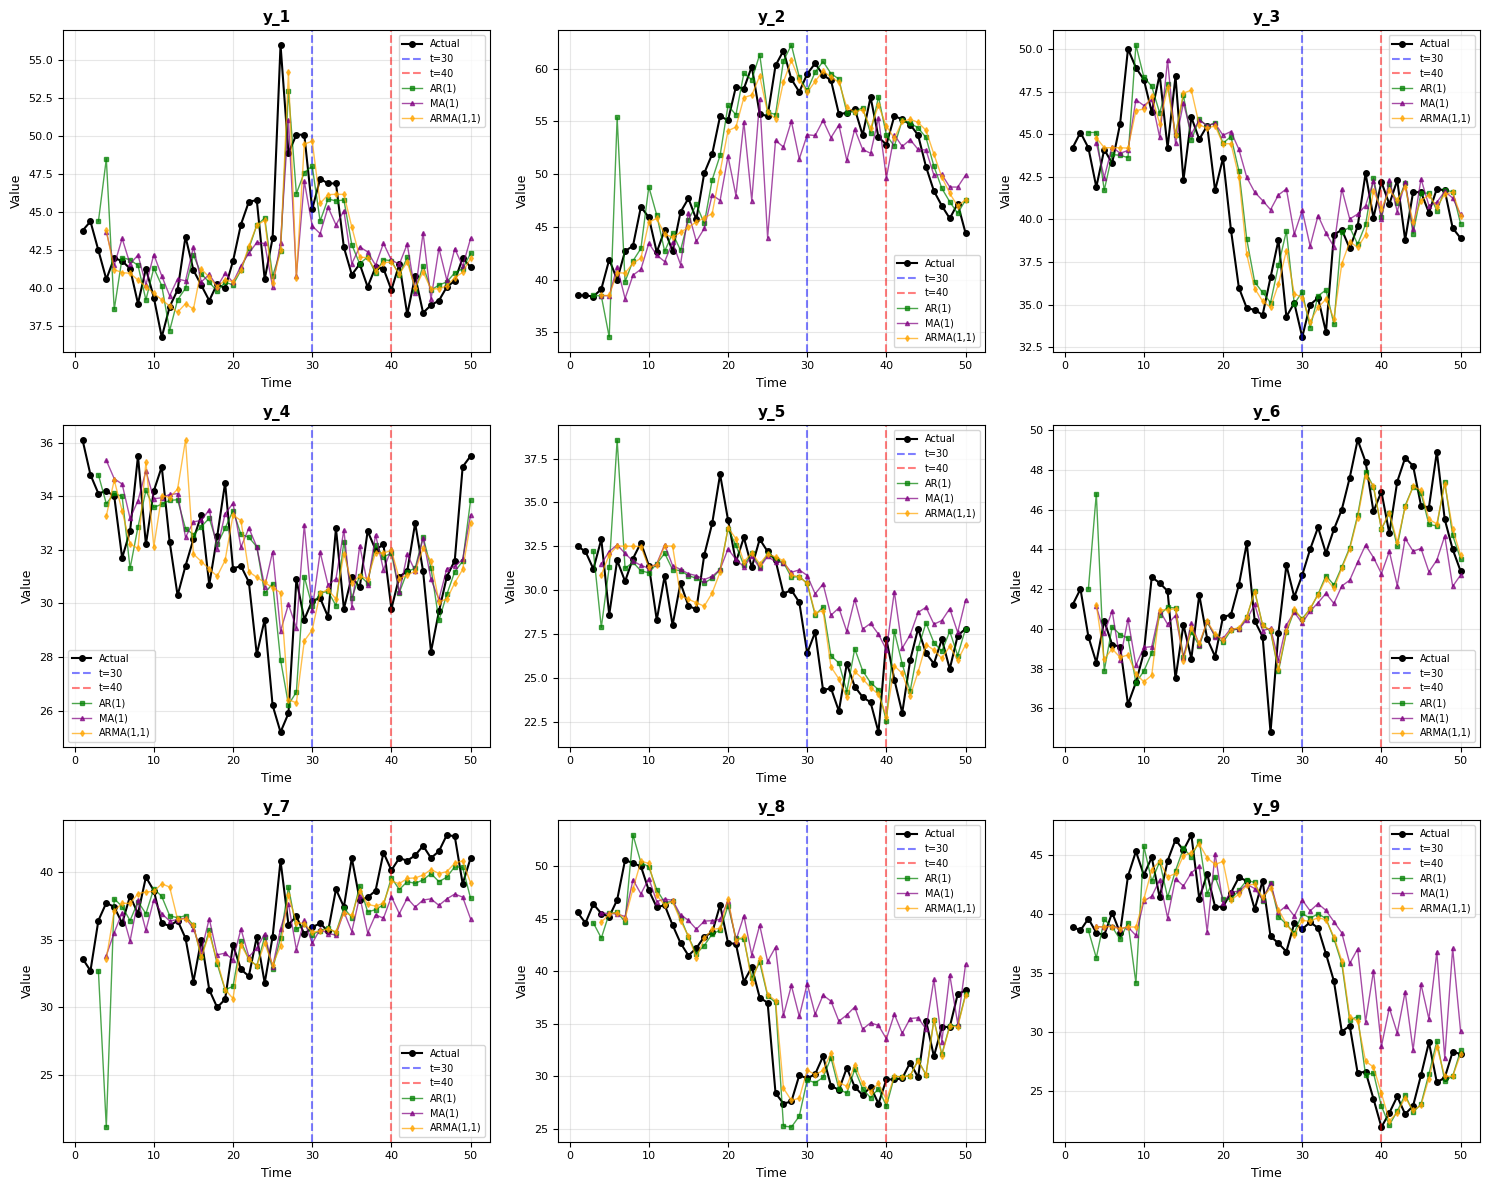

In [24]:
# Create plots for each series showing actual vs forecasts
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, (name, y) in enumerate(zip(y_names, y_list)):
    ax = axes[i]
    
    # Generate rolling forecasts (Part 1 approach)
    f_ar1 = ar1_forecast(y)
    f_ma1 = ma1_forecast(y, criterion="SSE")
    f_arma = arma11_forecast(y, criterion="SSE")
    
    # Generate fixed forecasts for t=41..50 (Part 2 approach)
    y_40 = y[:40]
    mu_ar1, phi_ar1 = estimate_ar1_params(y_40)
    mu_ma1, theta_ma1 = estimate_ma1_params(y_40, criterion="SSE")
    c_arma, phi_arma, theta_arma = estimate_arma11_params(y_40, criterion="SSE")
    
    f_ar1_fix = fixed_ar1_one_step_forecasts(y, mu_ar1, phi_ar1, 40)
    f_ma1_fix = fixed_ma1_one_step_forecasts(y, mu_ma1, theta_ma1, 40)
    f_arma_fix = fixed_arma11_one_step_forecasts(y, c_arma, phi_arma, theta_arma, 40)
    
    # Combine: use rolling forecasts up to t=40, then fixed forecasts for t=41..50
    f_ar1_combined = np.copy(f_ar1)
    f_ma1_combined = np.copy(f_ma1)
    f_arma_combined = np.copy(f_arma)
    
    f_ar1_combined[40:] = f_ar1_fix[40:]
    f_ma1_combined[40:] = f_ma1_fix[40:]
    f_arma_combined[40:] = f_arma_fix[40:]
    
    # Plot actual values
    ax.plot(range(1, N+1), y, 'ko-', label='Actual', markersize=4, linewidth=1.5)
    
    # Add vertical lines to mark periods
    ax.axvline(x=30, color='blue', linestyle='--', alpha=0.5, linewidth=1.5, label='t=30')
    ax.axvline(x=40, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='t=40')
    
    # Plot forecasts for each method
    ax.plot(range(1, N+1), f_ar1_combined, 's-', color='green', 
            label='AR(1)', markersize=3, alpha=0.7, linewidth=1)
    ax.plot(range(1, N+1), f_ma1_combined, '^-', color='purple', 
            label='MA(1)', markersize=3, alpha=0.7, linewidth=1)
    ax.plot(range(1, N+1), f_arma_combined, 'd-', color='orange', 
            label='ARMA(1,1)', markersize=3, alpha=0.7, linewidth=1)
    
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Time', fontsize=9)
    ax.set_ylabel('Value', fontsize=9)
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('arma_forecasts_all_series.png', dpi=300, bbox_inches='tight')
plt.show()

## Residual Diagnostics

In [25]:
import numpy as np

# ----------------------------------------------------------------------
# Helper: closed-form OLS for z = mu + phi x + e
# ----------------------------------------------------------------------
def _ols_intercept_slope(x, z):
    """
    Closed-form OLS for z = mu + phi x + e.
    Returns (mu_hat, phi_hat).
    """
    x = np.asarray(x, dtype=float)
    z = np.asarray(z, dtype=float)

    x_mean = float(np.mean(x))
    z_mean = float(np.mean(z))

    sxx = float(np.sum((x - x_mean) ** 2))
    if sxx == 0.0:
        phi_hat = 0.0
    else:
        sxz = float(np.sum((x - x_mean) * (z - z_mean)))
        phi_hat = sxz / sxx

    mu_hat = z_mean - phi_hat * x_mean
    return float(mu_hat), float(phi_hat)


# ----------------------------------------------------------------------
# 1) AR(1): compute one-step-ahead residuals using OLS estimates
# ----------------------------------------------------------------------
def compute_residuals_ar1(y, mu=None, phi=None):
    """
    Compute one-step-ahead forecast errors (residuals) for an AR(1) model:
        y_t = mu + phi y_{t-1} + e_t

    If (mu, phi) are not provided, estimate them by closed-form OLS on the full series.

    Returns
    -------
    residuals : np.ndarray
        Same length as y; residuals[0] = NaN (no lagged value).
    mu, phi : float
        Estimated or supplied parameters.
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    residuals = np.full(n, np.nan, dtype=float)

    if mu is None or phi is None:
        # OLS on (y_{t-1}, y_t) for t=1..n-1
        y_lag = y[:-1]
        y_dep = y[1:]
        mu, phi = _ols_intercept_slope(y_lag, y_dep)

    # One-step-ahead residuals using fitted parameters
    for t in range(1, n):
        residuals[t] = y[t] - (mu + phi * y[t - 1])

    return residuals, float(mu), float(phi)


# ----------------------------------------------------------------------
# 2) MA(1): estimate (mu, theta) by grid search, then compute residuals
# ----------------------------------------------------------------------
def compute_residuals_ma1(
    y,
    mu=None,
    theta=None,
    criterion="SSE",
    theta_grid=None,
    mu_grid=None,
    mu_span=0.2,
    mu_points=11
):
    """
    Compute one-step-ahead forecast errors (residuals) for an MA(1) model:
        y_t = mu + e_t + theta e_{t-1}

    If (mu, theta) are not provided, estimate them by grid search that minimizes
    ma1_objective(params, y, criterion).

    Grid defaults:
    - theta in [-0.99, 0.99]
    - mu around sample mean: mean*(1-mu_span) ... mean*(1+mu_span)

    Returns
    -------
    residuals : np.ndarray
        Same length as y; residuals[0] = NaN.
    mu, theta : float
        Estimated or supplied parameters.
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    residuals = np.full(n, np.nan, dtype=float)

    if mu is None or theta is None:
        # Build default grids if not provided
        if theta_grid is None:
            theta_grid = np.linspace(-0.99, 0.99, 101)

        y_mean = float(np.mean(y))
        if mu_grid is None:
            # Search mu in a small neighborhood around the sample mean
            mu_grid = np.linspace(y_mean * (1 - mu_span), y_mean * (1 + mu_span), mu_points)

        best_score = float("inf")
        best_mu, best_theta = y_mean, 0.0

        # Brute-force grid search
        for mu_cand in mu_grid:
            for theta_cand in theta_grid:
                score = ma1_objective([mu_cand, theta_cand], y, criterion=criterion)
                if score < best_score:
                    best_score = score
                    best_mu, best_theta = float(mu_cand), float(theta_cand)

        mu, theta = best_mu, best_theta

    # Compute one-step-ahead residuals with the chosen parameters
    eps = 0.0
    for t in range(n):
        if t == 0:
            residuals[t] = np.nan
        else:
            pred = mu + theta * eps
            residuals[t] = y[t] - pred

        # Update epsilon for next step (recursive MA error)
        eps = y[t] - (mu + theta * eps)

    return residuals, float(mu), float(theta)


# ----------------------------------------------------------------------
# 3) ARMA(1,1): estimate (c, phi, theta) by grid search, then compute residuals
# ----------------------------------------------------------------------
def compute_residuals_arma11(
    y,
    c=None,
    phi=None,
    theta=None,
    criterion="SSE",
    phi_grid=None,
    theta_grid=None,
    c_grid=None,
    c_scale=(0.9, 1.0, 1.1)
):
    """
    Compute one-step-ahead forecast errors (residuals) for an ARMA(1,1) model:
        y_t = c + phi y_{t-1} + e_t + theta e_{t-1}

    If (c, phi, theta) are not provided, estimate them by grid search minimizing
    arma11_objective(params, y, criterion).

    Grid defaults:
    - phi in [-0.99, 0.99]
    - theta in [-0.99, 0.99]
    - c is centered around c_approx = mean(y) * (1 - phi), scaled by c_scale

    Returns
    -------
    residuals : np.ndarray
        Same length as y; residuals[0] = NaN.
    c, phi, theta : float
        Estimated or supplied parameters.
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    residuals = np.full(n, np.nan, dtype=float)

    if c is None or phi is None or theta is None:
        if phi_grid is None:
            phi_grid = np.linspace(-0.99, 0.99, 101)
        if theta_grid is None:
            theta_grid = np.linspace(-0.99, 0.99, 101)

        y_mean = float(np.mean(y))

        best_score = float("inf")
        best_c, best_phi, best_theta = 0.0, 0.0, 0.0

        # Brute-force grid search
        for phi_cand in phi_grid:
            # Center c around the unconditional-mean relationship: mean ≈ c / (1 - phi)
            c_approx = y_mean * (1 - float(phi_cand))

            # If user did not provide a c_grid, build a small local grid around c_approx
            if c_grid is None:
                c_candidates = [c_approx * s for s in c_scale]
            else:
                c_candidates = c_grid

            for c_cand in c_candidates:
                for theta_cand in theta_grid:
                    score = arma11_objective([c_cand, phi_cand, theta_cand], y, criterion=criterion)
                    if score < best_score:
                        best_score = score
                        best_c = float(c_cand)
                        best_phi = float(phi_cand)
                        best_theta = float(theta_cand)

        c, phi, theta = best_c, best_phi, best_theta

    # Compute one-step-ahead residuals with the chosen parameters
    eps = 0.0
    for t in range(1, n):
        pred = c + phi * y[t - 1] + theta * eps
        residuals[t] = y[t] - pred
        eps = residuals[t]  # Update lagged error

    return residuals, float(c), float(phi), float(theta)

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import shapiro, probplot
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression

# ----------------------------------------------------------------------
# 1. Functions to compute in‑sample one‑step‑ahead residuals
#    (using parameters estimated on the full series or a fixed training set)
# ----------------------------------------------------------------------

# def compute_residuals_ar1(y, mu=None, phi=None):
#     """
#     Compute one-step-ahead forecast errors (residuals) for an AR(1) model.
    
#     Parameters
#     ----------
#     y : array_like
#         Time series.
#     mu, phi : float, optional
#         AR(1) parameters. If not provided, they are estimated from the entire series
#         via linear regression (as in ar1_forecast).
    
#     Returns
#     -------
#     residuals : np.ndarray
#         Array of residuals, same length as y. First element is NaN.
#     """
#     y = np.asarray(y, dtype=float)
#     n = len(y)
#     residuals = np.full(n, np.nan)
    
#     if mu is None or phi is None:
#         # Estimate parameters using the whole series
#         y_dep = y[1:]
#         y_lag = y[:-1].reshape(-1, 1)
#         model = LinearRegression().fit(y_lag, y_dep)
#         mu = model.intercept_
#         phi = model.coef_[0]
    
#     for t in range(1, n):
#         residuals[t] = y[t] - (mu + phi * y[t-1])
    
#     return residuals, mu, phi


# def compute_residuals_ma1(y, mu=None, theta=None, criterion="SSE"):
#     """
#     Compute one-step-ahead forecast errors (residuals) for an MA(1) model.
    
#     Parameters
#     ----------
#     y : array_like
#         Time series.
#     mu, theta : float, optional
#         MA(1) parameters. If not provided, they are estimated by minimising
#         the in‑sample SSE (or other criterion) on the entire series.
#     criterion : str, optional
#         Loss criterion passed to ma1_objective (default "SSE").
    
#     Returns
#     -------
#     residuals : np.ndarray
#         Array of residuals, same length as y. First element is NaN.
#     mu, theta : float
#         Estimated (or supplied) parameters.
#     """
#     y = np.asarray(y, dtype=float)
#     n = len(y)
#     residuals = np.full(n, np.nan)
    
#     if mu is None or theta is None:
#         res = minimize(
#             ma1_objective,
#             [np.mean(y), 0.1],
#             args=(y, criterion),
#             bounds=[(None, None), (-1, 1)]
#         )
#         mu, theta = res.x
    
#     eps = 0.0
#     for t in range(n):
#         if t == 0:
#             residuals[t] = np.nan
#         else:
#             pred = mu + theta * eps
#             residuals[t] = y[t] - pred
#         eps = y[t] - (mu + theta * eps) if t < n-1 else 0  # update error for next step
    
#     return residuals, mu, theta


# def compute_residuals_arma11(y, c=None, phi=None, theta=None, criterion="SSE"):
#     """
#     Compute one-step-ahead forecast errors (residuals) for an ARMA(1,1) model.
    
#     Parameters
#     ----------
#     y : array_like
#         Time series.
#     c, phi, theta : float, optional
#         ARMA(1,1) parameters. If not provided, they are estimated by minimising
#         the in‑sample SSE (or other criterion) on the entire series.
#     criterion : str, optional
#         Loss criterion passed to arma11_objective (default "SSE").
    
#     Returns
#     -------
#     residuals : np.ndarray
#         Array of residuals, same length as y. First element is NaN.
#     c, phi, theta : float
#         Estimated (or supplied) parameters.
#     """
#     y = np.asarray(y, dtype=float)
#     n = len(y)
#     residuals = np.full(n, np.nan)
    
#     if c is None or phi is None or theta is None:
#         res = minimize(
#             arma11_objective,
#             [np.mean(y) * 0.1, 0.5, 0.1],
#             args=(y, criterion),
#             bounds=[(None, None), (-1, 1), (-1, 1)]
#         )
#         c, phi, theta = res.x
    
#     eps = 0.0
#     for t in range(1, n):
#         pred = c + phi * y[t-1] + theta * eps
#         residuals[t] = y[t] - pred
#         eps = residuals[t]   # update the lagged error
    
#     return residuals, c, phi, theta


# ----------------------------------------------------------------------
# 2. Diagnostic functions
# ----------------------------------------------------------------------

def residual_diagnostics(residuals, series_name, model_name, lags=10, figsize=(12, 4), save=True, save_dir="plots"):
    """
    Perform standard residual diagnostics: ACF, PACF, Ljung–Box test,
    and a Q-Q plot for normality. The number of lags is automatically
    reduced if it exceeds half the available sample size.

    Parameters
    ----------
    residuals : array_like
        One-step-ahead forecast errors (may contain NaN at the beginning).
    series_name : str
        Name of the time series (for plot titles).
    model_name : str
        Name of the model (AR(1), MA(1), ARMA(1,1)).
    lags : int, optional
        Requested number of lags. Will be capped to max(1, n_obs//2 - 1).
    figsize : tuple, optional
        Size of the figure.

    Returns
    -------
    lb_pvalue : float
        Ljung–Box test p-value at the (possibly reduced) lag.
    """
    # Remove leading NaN values (forecast errors for the first observation)
    res = residuals[~np.isnan(residuals)]
    n_obs = len(res)

    # Adjust lags if necessary
    max_safe_lags = n_obs // 2 - 1
    if lags > max_safe_lags:
        old_lags = lags
        lags = max(1, max_safe_lags)
        print(f"Warning: Requested lags={old_lags} exceeds half the sample size "
              f"({n_obs}). Using lags={lags} instead.")
    
    if n_obs < lags + 1:
        print(f"Error: Not enough observations ({n_obs}) for lags={lags}. Skipping plots.")
        return np.nan

    # Create diagnostic plots
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # ACF
    plot_acf(res, ax=axes[0], lags=lags, title=f'ACF - {series_name} ({model_name})')
    axes[0].set_xlabel('Lag')
    
    # PACF (use Yule-Walker method which is standard for stationary series)
    plot_pacf(res, ax=axes[1], lags=lags, title=f'PACF - {series_name} ({model_name})',
              method='ywm')
    axes[1].set_xlabel('Lag')
    
    # Q-Q plot for normality
    probplot(res, dist="norm", plot=axes[2])
    axes[2].set_title(f'Q-Q Plot - {series_name} ({model_name})')
    axes[2].set_xlabel('Theoretical quantiles')
    axes[2].set_ylabel('Sample quantiles')
    
    plt.tight_layout()

    # -------- Save automatically --------
    if save:
        safe_model = model_name.replace("(", "").replace(")", "").replace(",", "")
        filename = f"{series_name}_{safe_model}_diagnostics.png"
        full_path = os.path.join(save_dir, filename)
        plt.savefig(full_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {full_path}")
        
    plt.show()
    
    # Ljung–Box test for residual autocorrelation
    lb_test = acorr_ljungbox(res, lags=[lags], return_df=True)
    lb_pvalue = lb_test.iloc[0, 1]   # p-value at the specified lag
    print(f"Ljung–Box test (lag={lags}): p-value = {lb_pvalue:.4f}")
    
    # Shapiro–Wilk test for normality (optional)
    shapiro_stat, shapiro_p = shapiro(res)
    print(f"Shapiro–Wilk test: p-value = {shapiro_p:.4f}")
    
    return lb_pvalue


def summarize_ljungbox_pvalues(results_dict):
    """
    Create a summary DataFrame of Ljung–Box p-values for quick comparison.
    
    Parameters
    ----------
    results_dict : dict
        Nested dictionary: results_dict[series_name][model_name] = p-value.
    
    Returns
    -------
    pd.DataFrame
        Rows: model names, Columns: series names.
    """
    df = pd.DataFrame(results_dict).T
    return df


Residual Diagnostics: Gasoline Sales 1
Saved: plots\Gasoline1_AR1_diagnostics.png


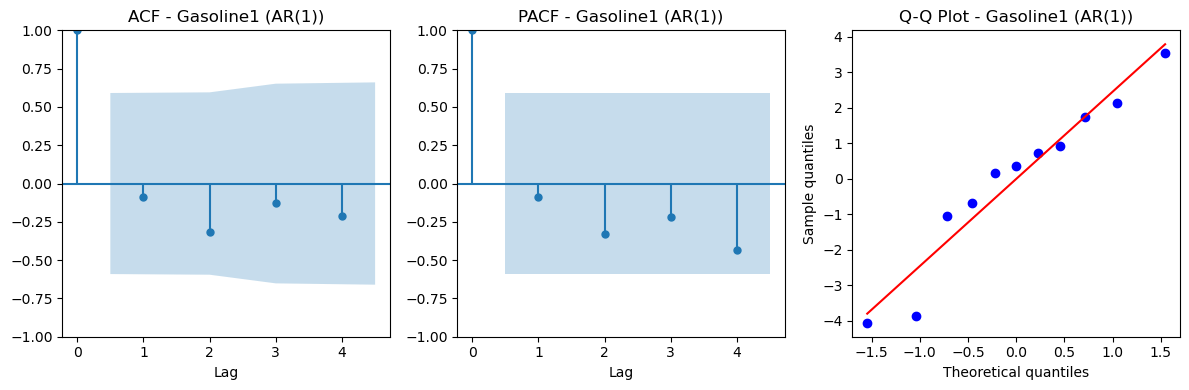

Ljung–Box test (lag=4): p-value = 0.5737
Shapiro–Wilk test: p-value = 0.4605
Saved: plots\Gasoline1_MA1_diagnostics.png


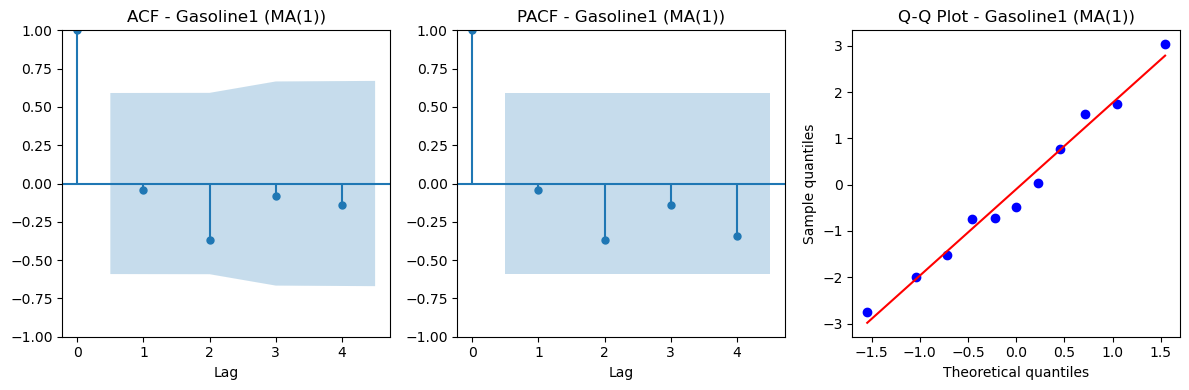

Ljung–Box test (lag=4): p-value = 0.6145
Shapiro–Wilk test: p-value = 0.9557
Saved: plots\Gasoline1_ARMA11_diagnostics.png


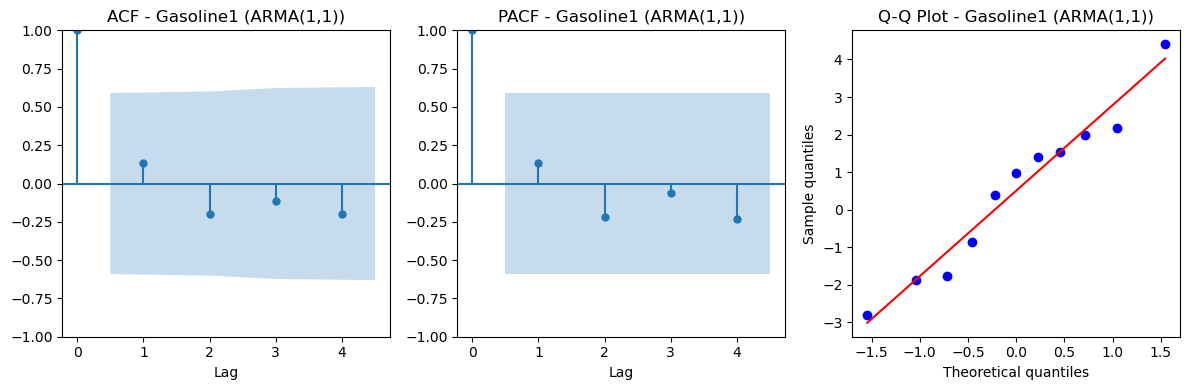

Ljung–Box test (lag=4): p-value = 0.7486
Shapiro–Wilk test: p-value = 0.7706

Residual Diagnostics: Gasoline Sales 2
Saved: plots\Gasoline2_AR1_diagnostics.png


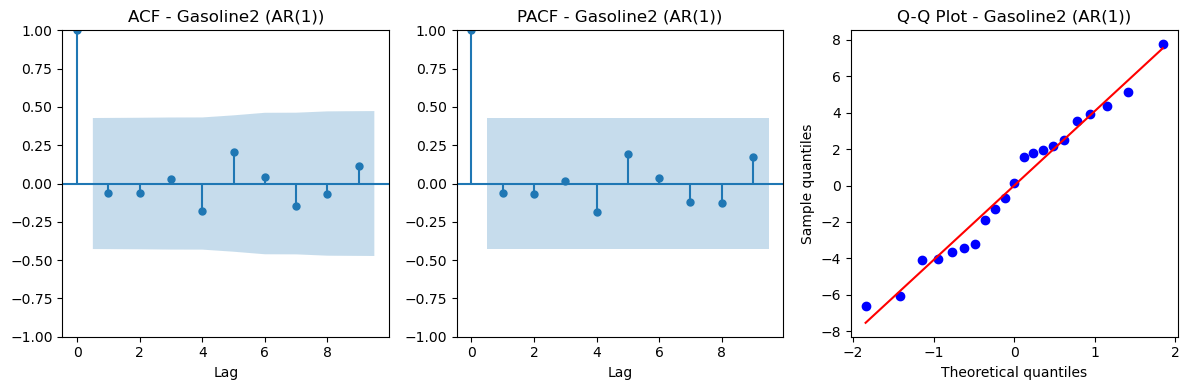

Ljung–Box test (lag=9): p-value = 0.9172
Shapiro–Wilk test: p-value = 0.7147
Saved: plots\Gasoline2_MA1_diagnostics.png


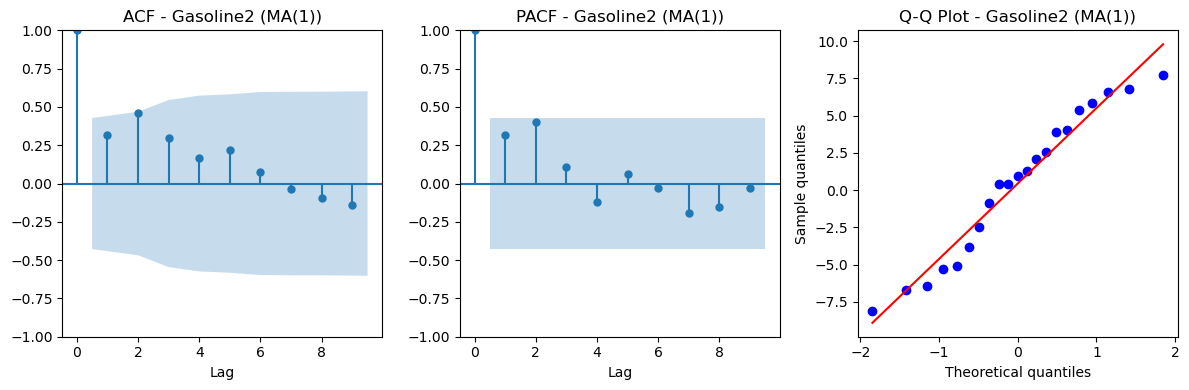

Ljung–Box test (lag=9): p-value = 0.1304
Shapiro–Wilk test: p-value = 0.2922
Saved: plots\Gasoline2_ARMA11_diagnostics.png


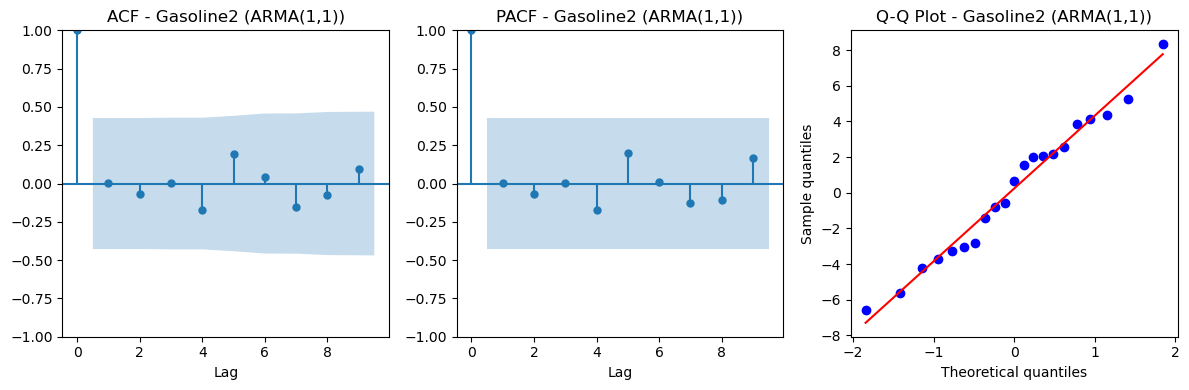

Ljung–Box test (lag=9): p-value = 0.9412
Shapiro–Wilk test: p-value = 0.8804


0.941211886634394

In [30]:
# Gasoline 1
print("\n" + "="*60)
print("Residual Diagnostics: Gasoline Sales 1")
print("="*60)

y_g1 = y_gas1   

# AR(1)
res_ar1, mu_ar1, phi_ar1 = compute_residuals_ar1(y_g1)
lb_p = residual_diagnostics(res_ar1, "Gasoline1", "AR(1)", lags=10)

res_ma1, mu_ma1, theta_ma1 = compute_residuals_ma1(y_g1)
lb_p = residual_diagnostics(res_ma1, "Gasoline1", "MA(1)", lags=10)


# ARMA(1,1)
res_arma, c_arma, phi_arma, theta_arma = compute_residuals_arma11(y_g1)
lb_p = residual_diagnostics(res_arma, "Gasoline1", "ARMA(1,1)", lags=10)


# Gasoline 2
print("\n" + "="*60)
print("Residual Diagnostics: Gasoline Sales 2")
print("="*60)

y_g2 = y_gas2   

res_ar1, _, _ = compute_residuals_ar1(y_g2)
residual_diagnostics(res_ar1, "Gasoline2", "AR(1)", lags=10)

res_ma1, _, _ = compute_residuals_ma1(y_g2)
residual_diagnostics(res_ma1, "Gasoline2", "MA(1)", lags=10)

res_arma, _, _, _ = compute_residuals_arma11(y_g2)
residual_diagnostics(res_arma, "Gasoline2", "ARMA(1,1)", lags=10)


Residual Diagnostics: Bicycle Sales
Saved: plots\Bicycle_AR1_diagnostics.png


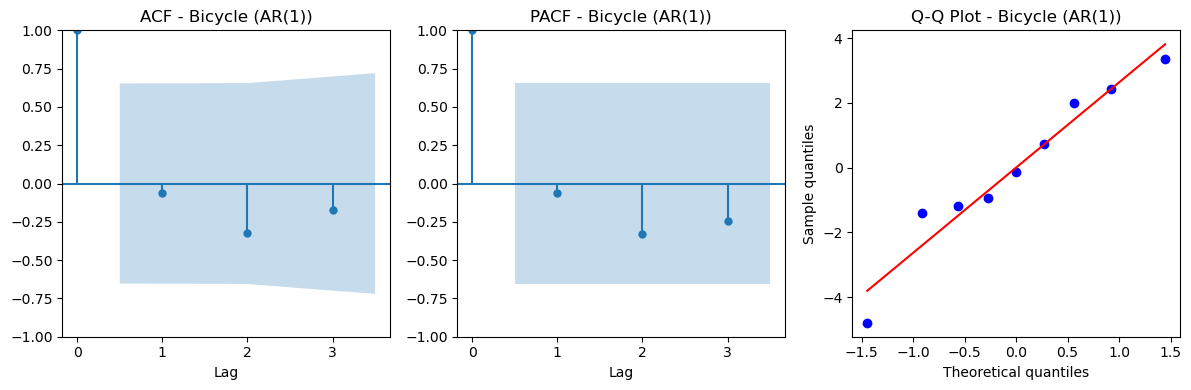

Ljung–Box test (lag=3): p-value = 0.5676
Shapiro–Wilk test: p-value = 0.7192
Saved: plots\Bicycle_MA1_diagnostics.png


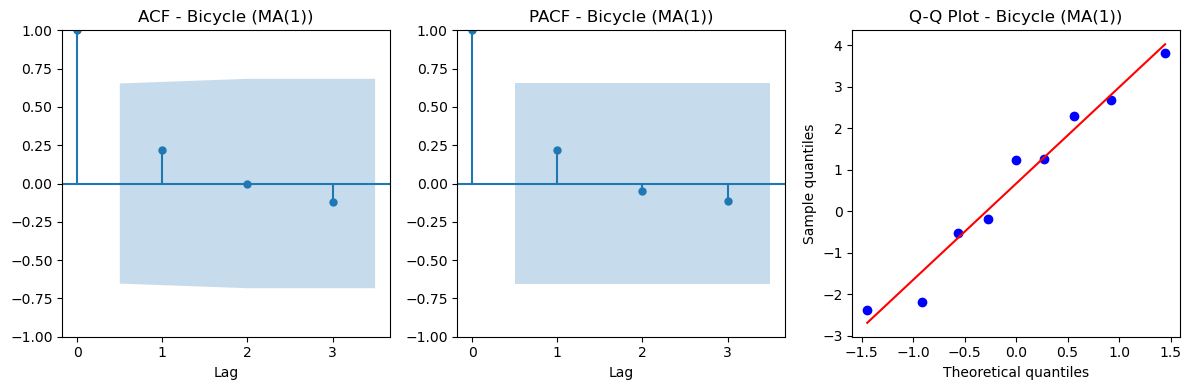

Ljung–Box test (lag=3): p-value = 0.8443
Shapiro–Wilk test: p-value = 0.7027
Saved: plots\Bicycle_ARMA11_diagnostics.png


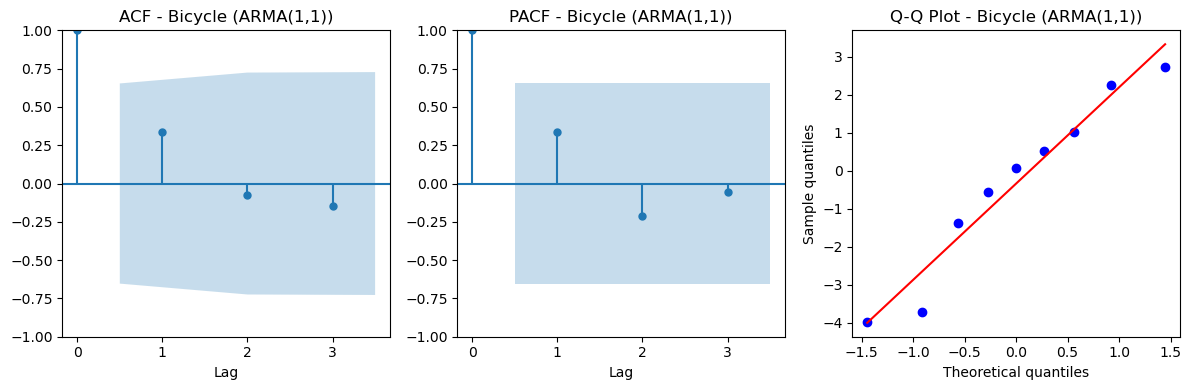

Ljung–Box test (lag=3): p-value = 0.6029
Shapiro–Wilk test: p-value = 0.5323


0.602919072656465

In [31]:
print("\n" + "="*60)
print("Residual Diagnostics: Bicycle Sales")
print("="*60)

y_bike = y_bike  

res_ar1, _, _ = compute_residuals_ar1(y_bike)
residual_diagnostics(res_ar1, "Bicycle", "AR(1)", lags=10)

res_ma1, _, _ = compute_residuals_ma1(y_bike)
residual_diagnostics(res_ma1, "Bicycle", "MA(1)", lags=10)

res_arma, _, _, _ = compute_residuals_arma11(y_bike)
residual_diagnostics(res_arma, "Bicycle", "ARMA(1,1)", lags=10)


Residual Diagnostics: 9 Series from DataAssignment1 (first 40 obs)
Saved: plots\y_1_AR1_diagnostics.png


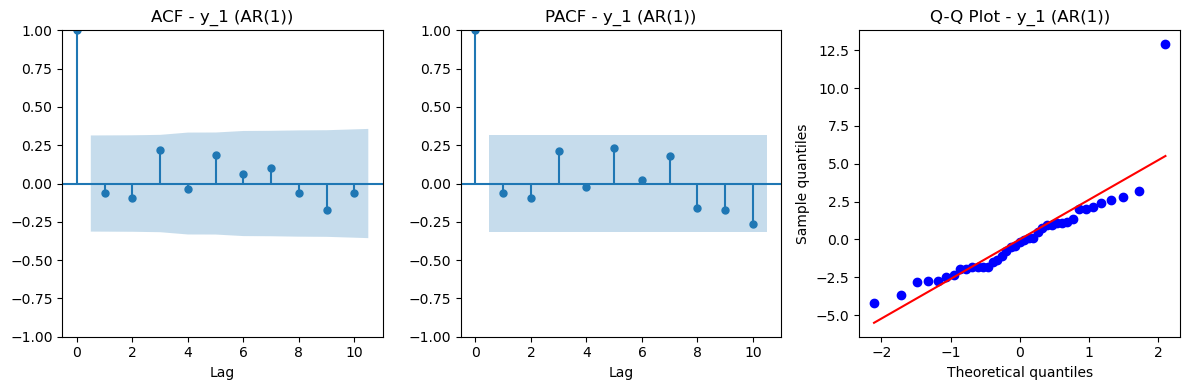

Ljung–Box test (lag=10): p-value = 0.7162
Shapiro–Wilk test: p-value = 0.0000
Saved: plots\y_1_MA1_diagnostics.png


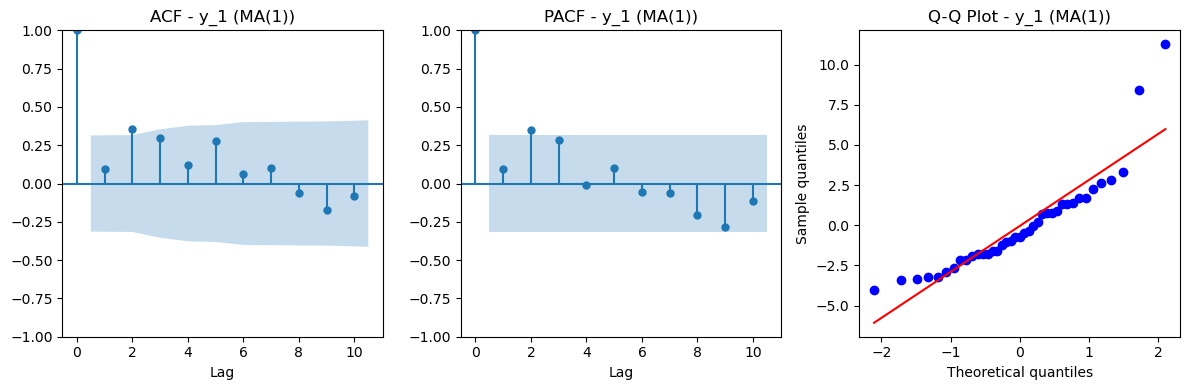

Ljung–Box test (lag=10): p-value = 0.0739
Shapiro–Wilk test: p-value = 0.0001
Saved: plots\y_1_ARMA11_diagnostics.png


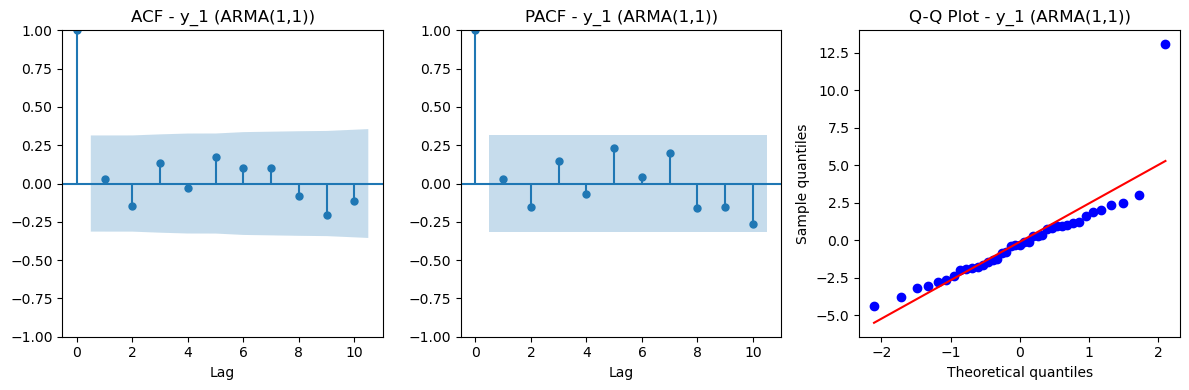

Ljung–Box test (lag=10): p-value = 0.6759
Shapiro–Wilk test: p-value = 0.0000
Saved: plots\y_2_AR1_diagnostics.png


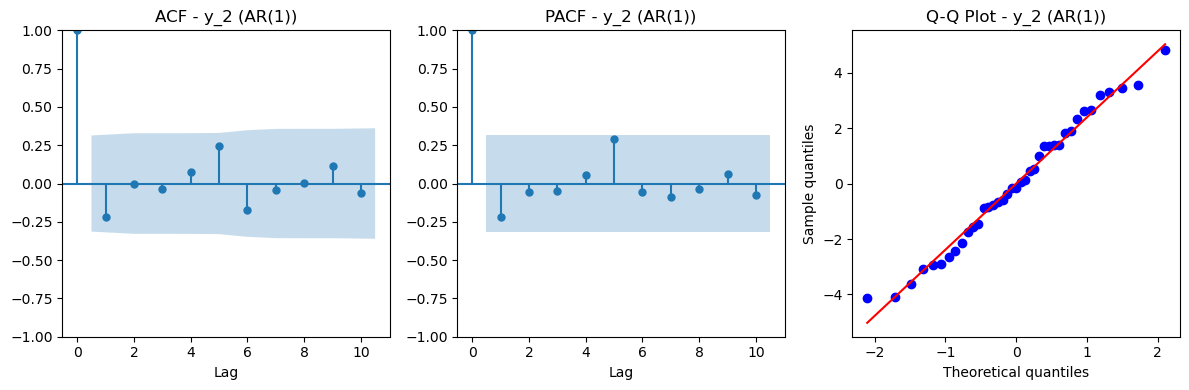

Ljung–Box test (lag=10): p-value = 0.6644
Shapiro–Wilk test: p-value = 0.6381
Saved: plots\y_2_MA1_diagnostics.png


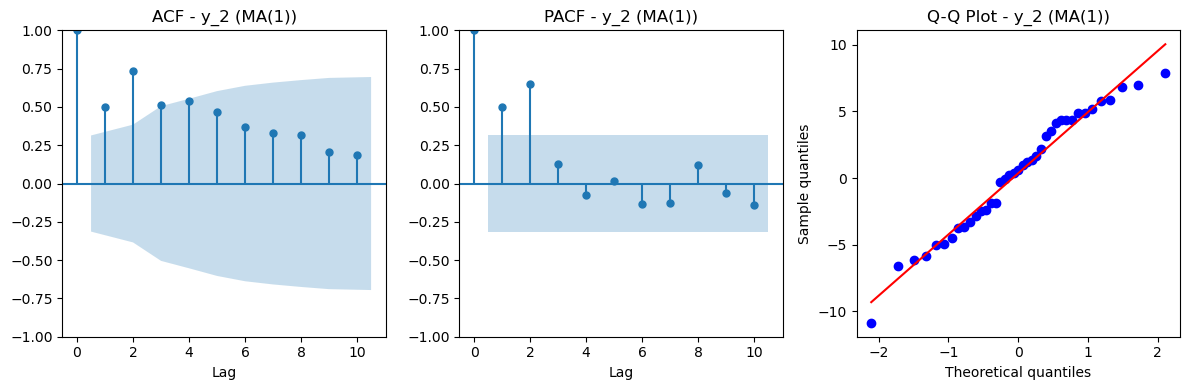

Ljung–Box test (lag=10): p-value = 0.0000
Shapiro–Wilk test: p-value = 0.3509
Saved: plots\y_2_ARMA11_diagnostics.png


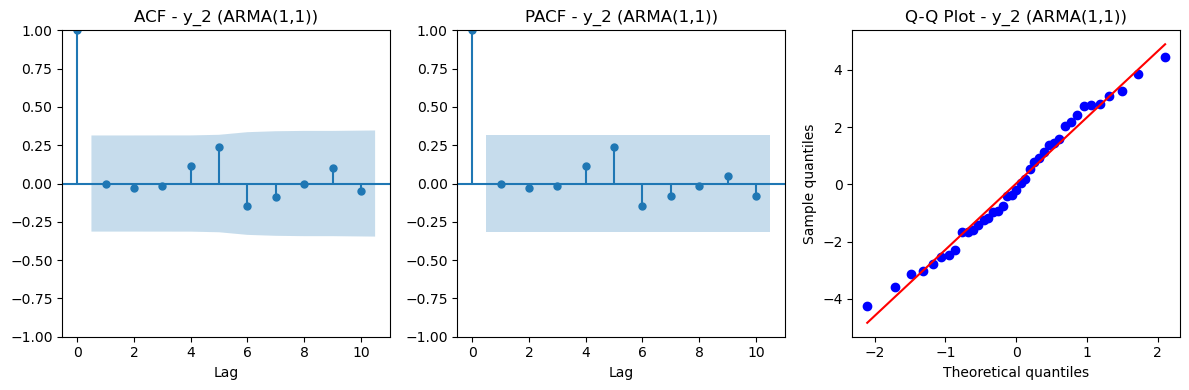

Ljung–Box test (lag=10): p-value = 0.8653
Shapiro–Wilk test: p-value = 0.5865
Saved: plots\y_3_AR1_diagnostics.png


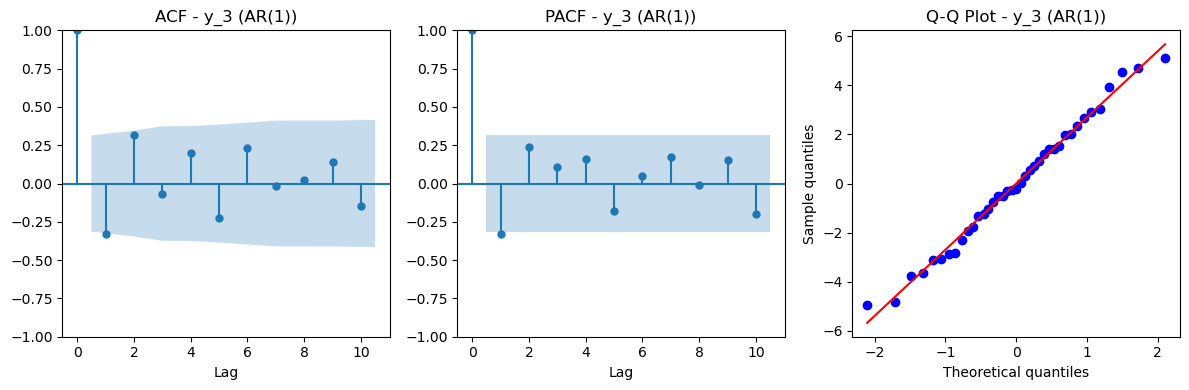

Ljung–Box test (lag=10): p-value = 0.0539
Shapiro–Wilk test: p-value = 0.8159
Saved: plots\y_3_MA1_diagnostics.png


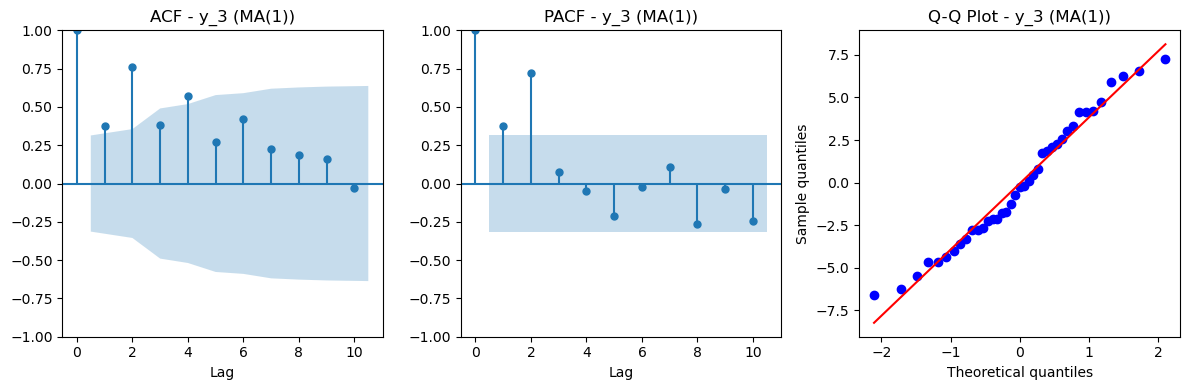

Ljung–Box test (lag=10): p-value = 0.0000
Shapiro–Wilk test: p-value = 0.3365
Saved: plots\y_3_ARMA11_diagnostics.png


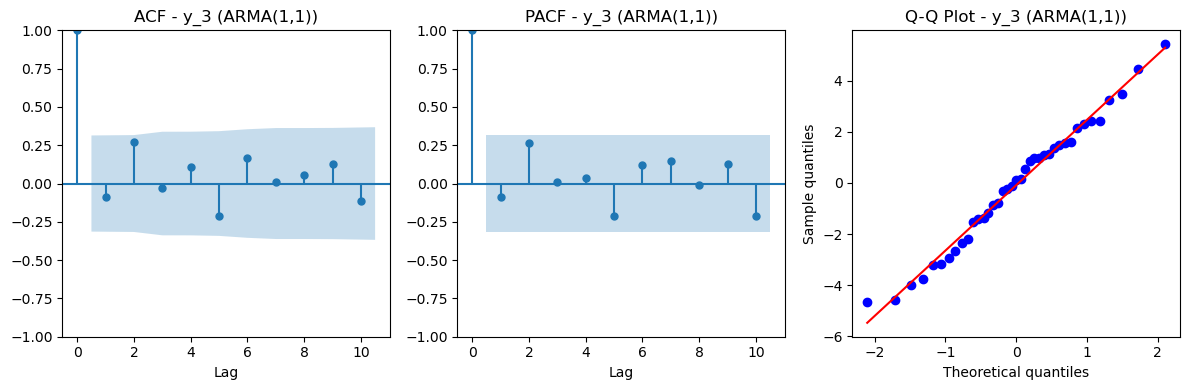

Ljung–Box test (lag=10): p-value = 0.5033
Shapiro–Wilk test: p-value = 0.7888
Saved: plots\y_4_AR1_diagnostics.png


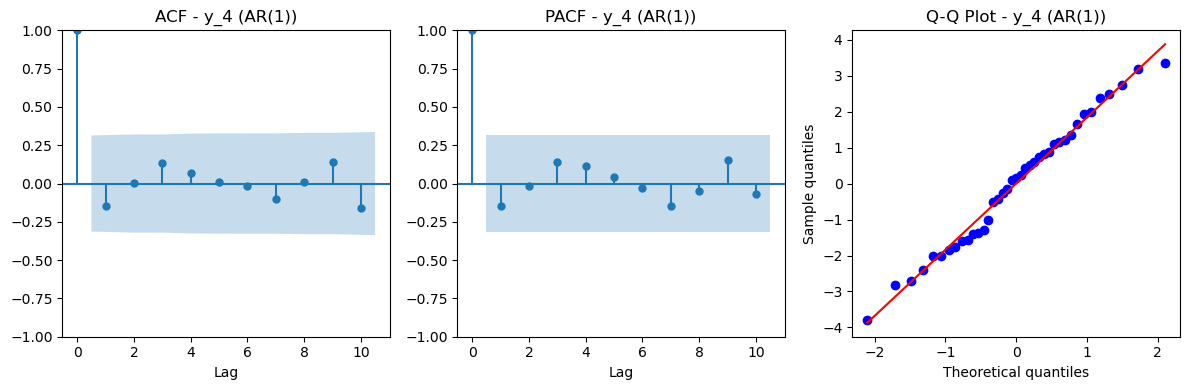

Ljung–Box test (lag=10): p-value = 0.8947
Shapiro–Wilk test: p-value = 0.7448
Saved: plots\y_4_MA1_diagnostics.png


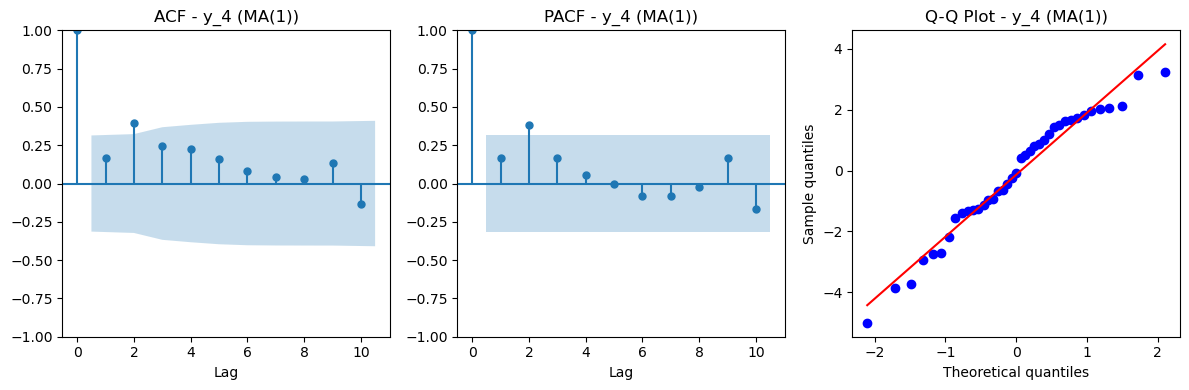

Ljung–Box test (lag=10): p-value = 0.0817
Shapiro–Wilk test: p-value = 0.2503
Saved: plots\y_4_ARMA11_diagnostics.png


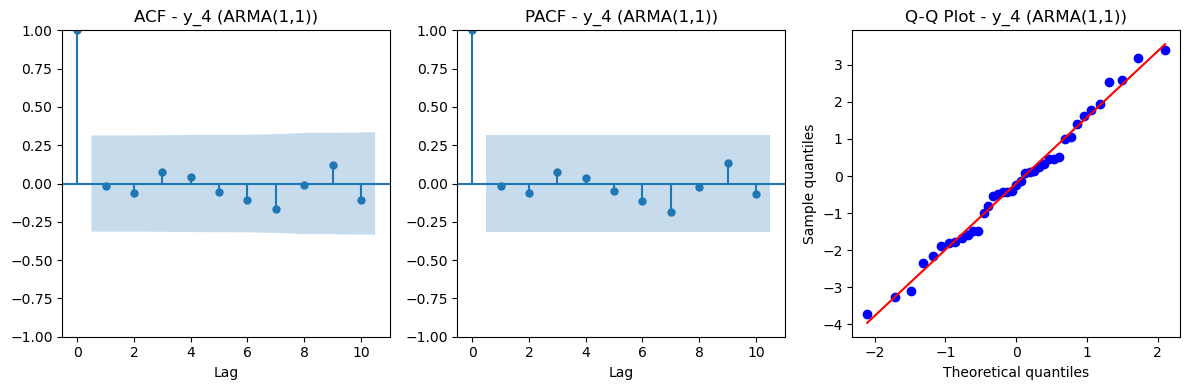

Ljung–Box test (lag=10): p-value = 0.9436
Shapiro–Wilk test: p-value = 0.8715
Saved: plots\y_5_AR1_diagnostics.png


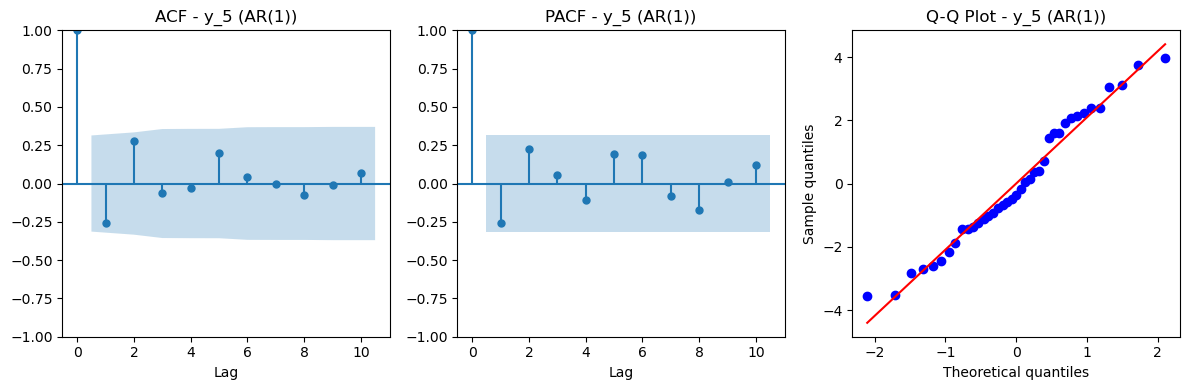

Ljung–Box test (lag=10): p-value = 0.5552
Shapiro–Wilk test: p-value = 0.3228
Saved: plots\y_5_MA1_diagnostics.png


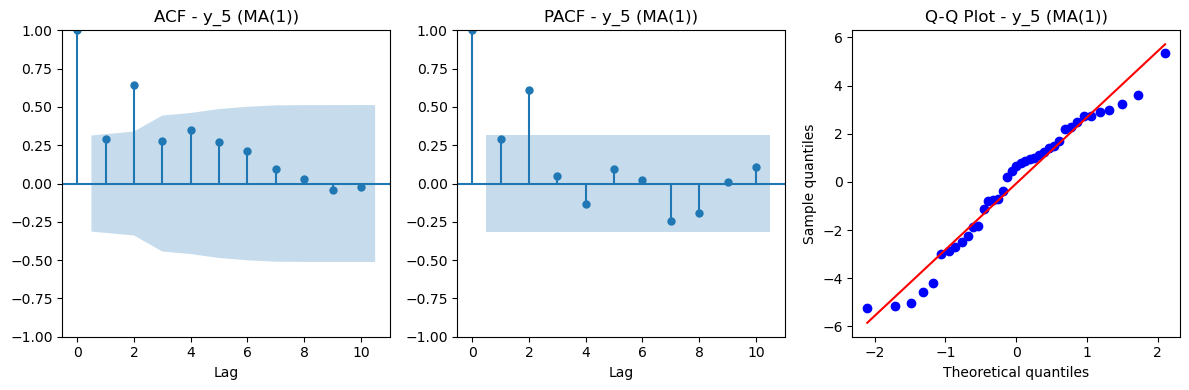

Ljung–Box test (lag=10): p-value = 0.0001
Shapiro–Wilk test: p-value = 0.1847
Saved: plots\y_5_ARMA11_diagnostics.png


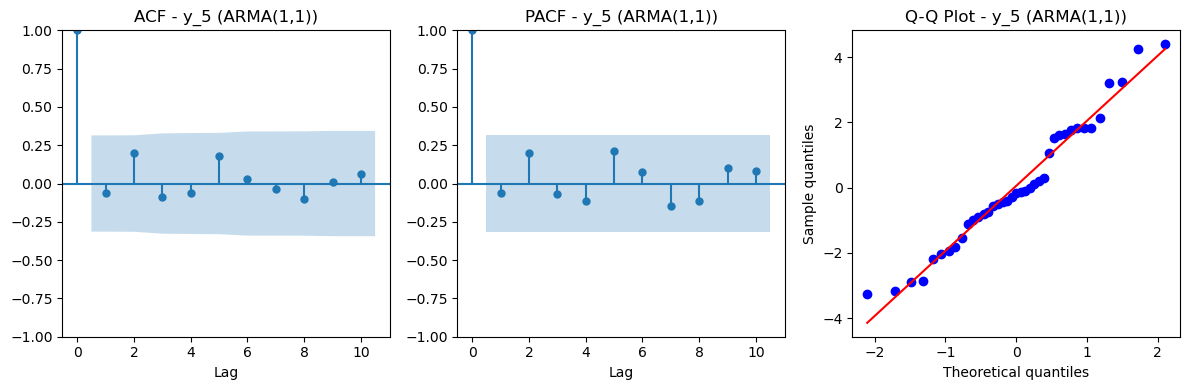

Ljung–Box test (lag=10): p-value = 0.9065
Shapiro–Wilk test: p-value = 0.2837
Saved: plots\y_6_AR1_diagnostics.png


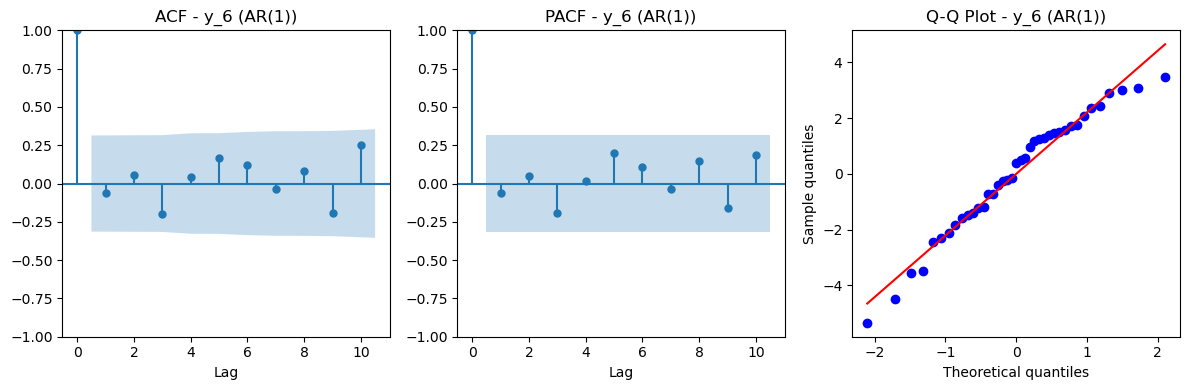

Ljung–Box test (lag=10): p-value = 0.4324
Shapiro–Wilk test: p-value = 0.2685
Saved: plots\y_6_MA1_diagnostics.png


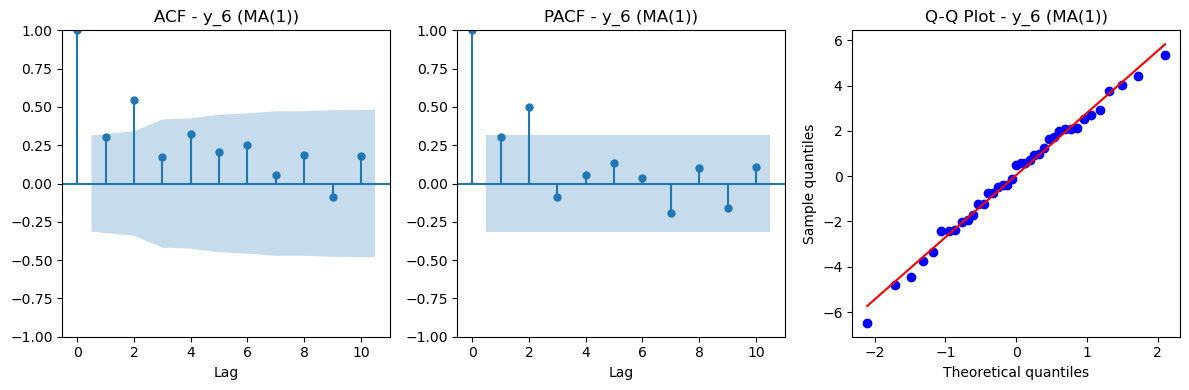

Ljung–Box test (lag=10): p-value = 0.0004
Shapiro–Wilk test: p-value = 0.9742
Saved: plots\y_6_ARMA11_diagnostics.png


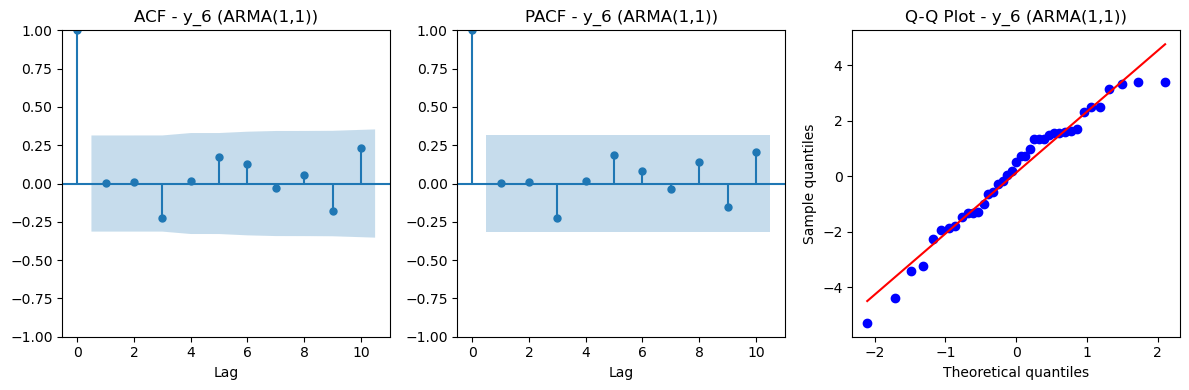

Ljung–Box test (lag=10): p-value = 0.4959
Shapiro–Wilk test: p-value = 0.2129
Saved: plots\y_7_AR1_diagnostics.png


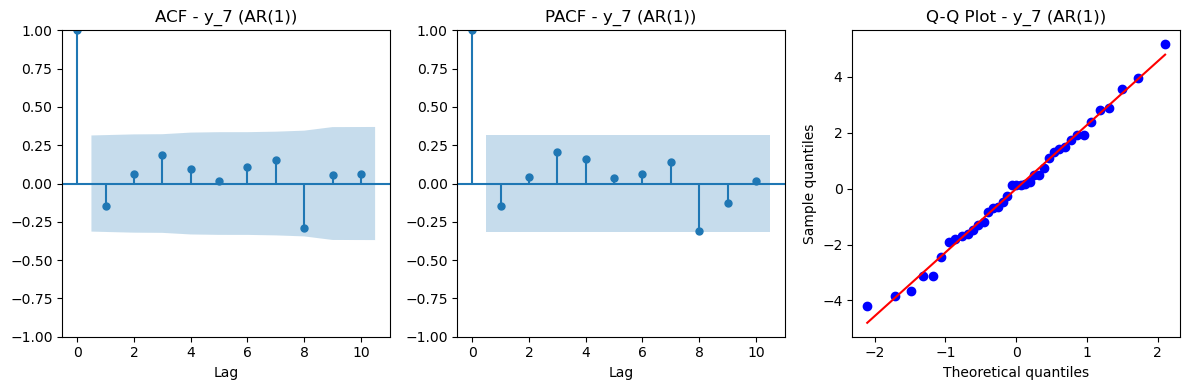

Ljung–Box test (lag=10): p-value = 0.4837
Shapiro–Wilk test: p-value = 0.9659
Saved: plots\y_7_MA1_diagnostics.png


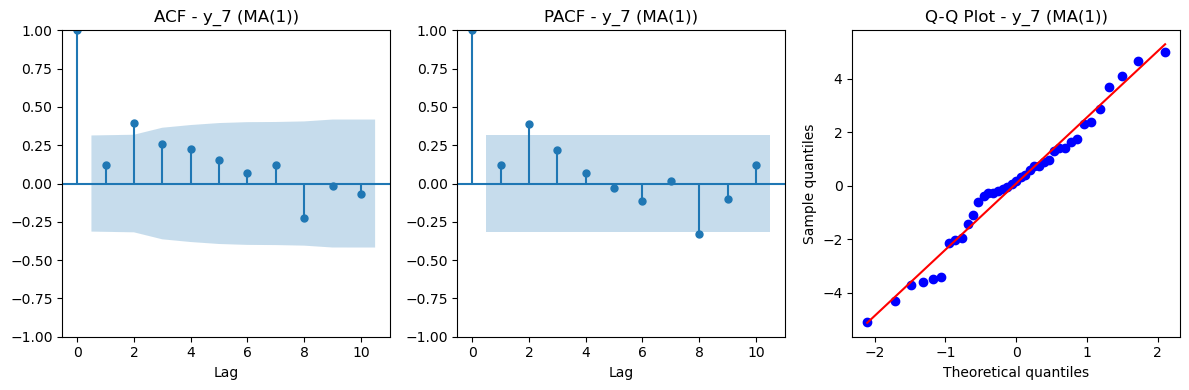

Ljung–Box test (lag=10): p-value = 0.0589
Shapiro–Wilk test: p-value = 0.5526
Saved: plots\y_7_ARMA11_diagnostics.png


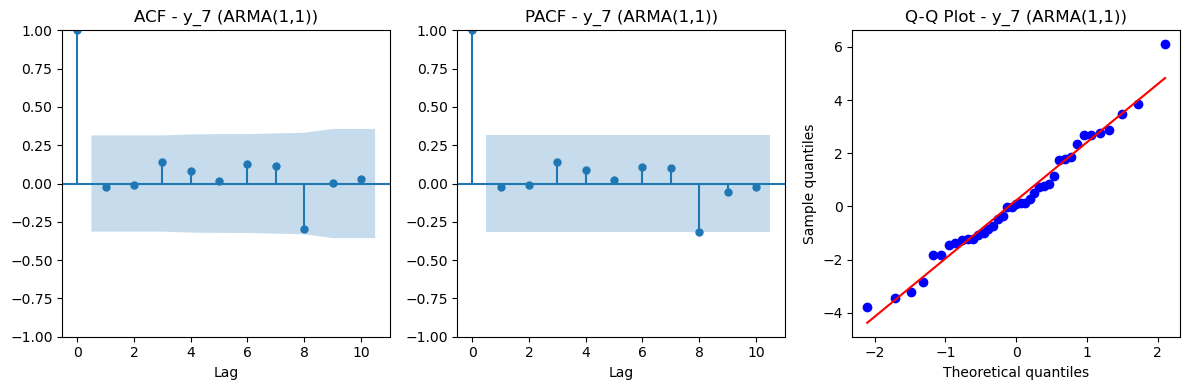

Ljung–Box test (lag=10): p-value = 0.7011
Shapiro–Wilk test: p-value = 0.6427
Saved: plots\y_8_AR1_diagnostics.png


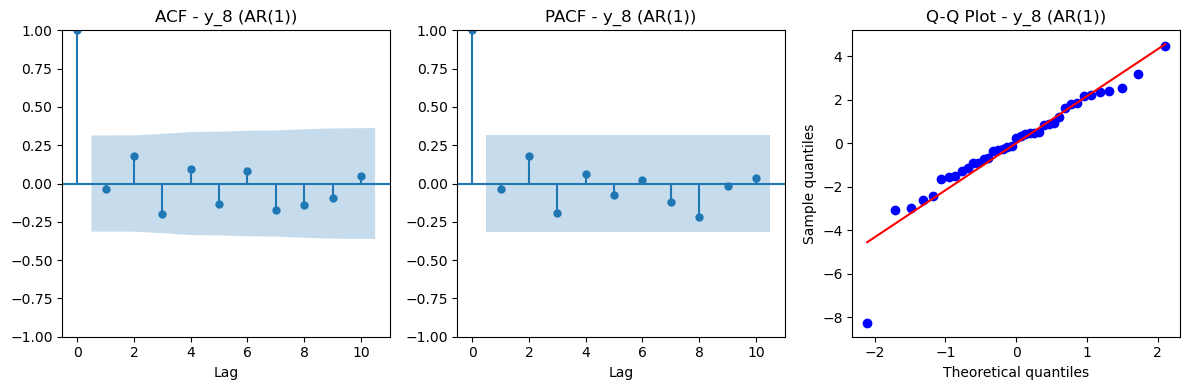

Ljung–Box test (lag=10): p-value = 0.6372
Shapiro–Wilk test: p-value = 0.0117
Saved: plots\y_8_MA1_diagnostics.png


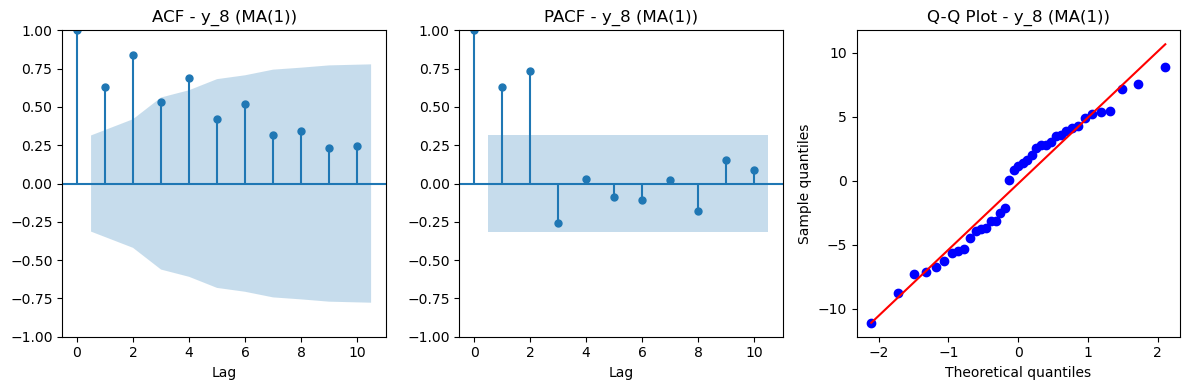

Ljung–Box test (lag=10): p-value = 0.0000
Shapiro–Wilk test: p-value = 0.1658
Saved: plots\y_8_ARMA11_diagnostics.png


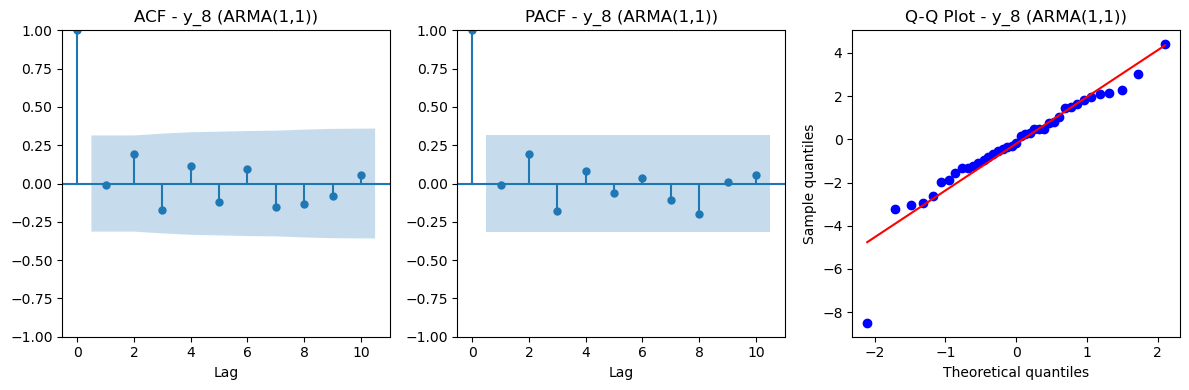

Ljung–Box test (lag=10): p-value = 0.6928
Shapiro–Wilk test: p-value = 0.0118
Saved: plots\y_9_AR1_diagnostics.png


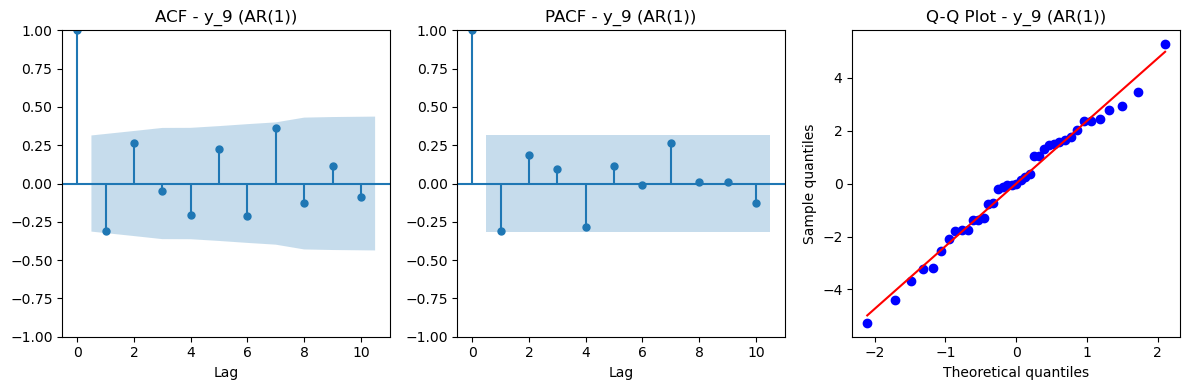

Ljung–Box test (lag=10): p-value = 0.0139
Shapiro–Wilk test: p-value = 0.9428
Saved: plots\y_9_MA1_diagnostics.png


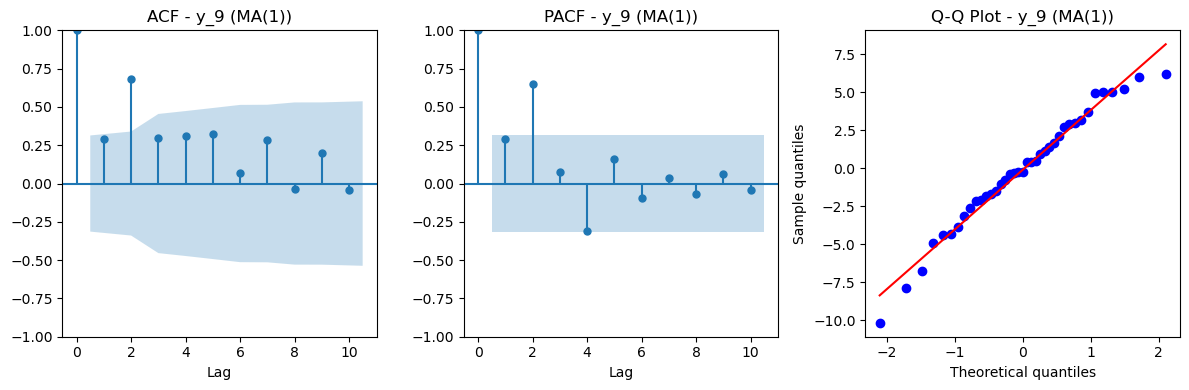

Ljung–Box test (lag=10): p-value = 0.0000
Shapiro–Wilk test: p-value = 0.4947
Saved: plots\y_9_ARMA11_diagnostics.png


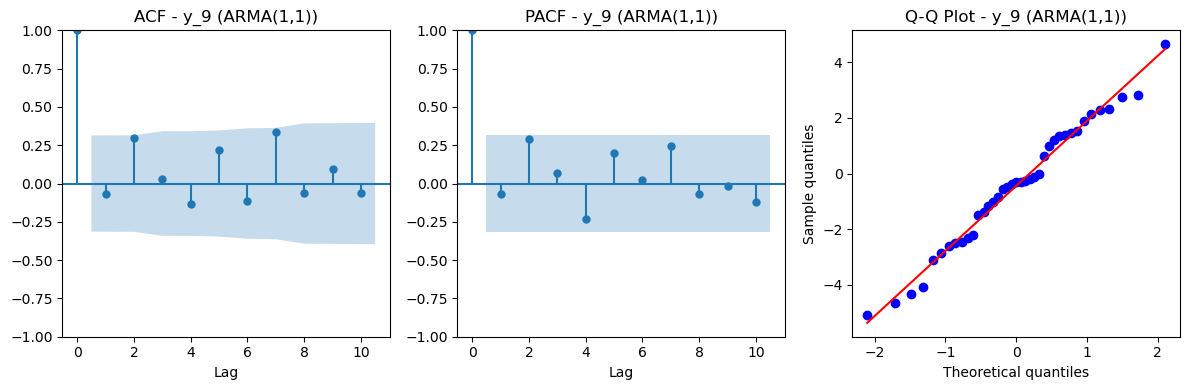

Ljung–Box test (lag=10): p-value = 0.1644
Shapiro–Wilk test: p-value = 0.7873

Ljung–Box p-values (lag=10) for the 9 series (training sample 1–40):


,AR(1),MA(1),"ARMA(1,1)"
y_1,0.716188,7.392631e-02,0.675903
y_2,0.664353,4.015316e-15,0.865322
y_3,0.053883,3.741585e-11,0.503300
y_4,0.894687,8.171674e-02,0.943596
y_5,0.555156,5.853453e-05,0.906547
y_6,0.432386,4.135717e-04,0.495918
y_7,0.483744,5.886186e-02,0.701150
y_8,0.637242,5.724764e-21,0.692821
y_9,0.013853,4.249298e-06,0.164384


In [32]:
print("\n" + "="*60)
print("Residual Diagnostics: 9 Series from DataAssignment1 (first 40 obs)")
print("="*60)

pvalue_dict = {}

for name, y in zip(y_names, y_list):
    y_train = y[:40]   # estimation sample
    pvalue_dict[name] = {}
    
    # AR(1)
    res_ar1, _, _ = compute_residuals_ar1(y_train)
    lb_p = residual_diagnostics(res_ar1, name, "AR(1)", lags=10)
    pvalue_dict[name]["AR(1)"] = lb_p
    
    # MA(1)
    res_ma1, _, _ = compute_residuals_ma1(y_train)
    lb_p = residual_diagnostics(res_ma1, name, "MA(1)", lags=10)
    pvalue_dict[name]["MA(1)"] = lb_p
    
    # ARMA(1,1)
    res_arma, _, _, _ = compute_residuals_arma11(y_train)
    lb_p = residual_diagnostics(res_arma, name, "ARMA(1,1)", lags=10)
    pvalue_dict[name]["ARMA(1,1)"] = lb_p

# Create summary table of Ljung–Box p-values
df_lb = summarize_ljungbox_pvalues(pvalue_dict)
print("\nLjung–Box p-values (lag=10) for the 9 series (training sample 1–40):")
display(df_lb)

## 2-step forecast

In [58]:
def align_h2_forecasts(y, forecast_from_origin_fn):
    """
    Returns f2 where f2[t+2] = yhat_{t+2|t}.
    forecast_from_origin_fn(y, t) must return the scalar 2-step forecast made at origin t
    using data up to and including y[t].
    """
    y = np.asarray(y, dtype=float)
    f2 = np.full(len(y), np.nan)
    for t in range(len(y) - 2):
        f2[t+2] = forecast_from_origin_fn(y, t)
    return f2

def rw_h2_origin(y, t):
    return y[t]

def rw_forecast_h2(y):
    return align_h2_forecasts(y, rw_h2_origin)

def running_avg_h2_origin(y, t):
    return np.mean(y[:t+1])

def running_average_forecast_h2(y):
    return align_h2_forecasts(y, running_avg_h2_origin)

def exp_smoothing_forecast_h2(y, alpha=0.2):
    y = np.asarray(y, dtype=float)
    f2 = np.full(len(y), np.nan)
    S = np.nan
    for t in range(len(y)):
        if t == 0:
            S = y[0]
        else:
            S = alpha * y[t] + (1 - alpha) * S
        # forecast made at t is used for t+2
        if t + 2 < len(y):
            f2[t+2] = S
    return f2

In [ ]:
# ----------------------------
# Closed-form OLS: z = mu + phi x + e
# ----------------------------
def _ols_intercept_slope(x, z):
    x = np.asarray(x, dtype=float)
    z = np.asarray(z, dtype=float)

    x_mean = float(np.mean(x))
    z_mean = float(np.mean(z))

    sxx = float(np.sum((x - x_mean) ** 2))
    if sxx == 0.0:
        phi_hat = 0.0
    else:
        sxz = float(np.sum((x - x_mean) * (z - z_mean)))
        phi_hat = sxz / sxx

    mu_hat = z_mean - phi_hat * x_mean
    return float(mu_hat), float(phi_hat)


# ============================================================
# AR(1): OLS expanding window, 2-step ahead
# y_{t+1|t} = mu + phi y_t
# y_{t+2|t} = mu + phi y_{t+1|t}
# ============================================================
def ar1_h2_origin_ols(y, t):
    if t < 1:
        return np.nan

    y_hist = np.asarray(y[:t+1], float)
    y_dep = y_hist[1:]
    y_lag = y_hist[:-1]

    mu, phi = _ols_intercept_slope(y_lag, y_dep)

    yhat1 = mu + phi * y_hist[-1]
    yhat2 = mu + phi * yhat1
    return float(yhat2)

def ar1_forecast_h2_ols(y):
    return align_h2_forecasts(y, ar1_h2_origin_ols)


# ============================================================
# MA(1): grid search (mu, theta) using ma1_objective,
# then 2-step forecast is mu (for MA(1) with zero-mean future eps)
# ============================================================
def ma1_objective(params, y, criterion="MSE"):
    mu, theta = params
    eps = 0.0
    errs = []
    for val in y:
        err = val - (mu + theta * eps)
        errs.append(err)
        eps = err
    errs = np.asarray(errs, dtype=float)
    if criterion == "SSE":
        return float(np.sum(errs**2))
    elif criterion == "MSE":
        return float(np.mean(errs**2))
    elif criterion == "MAE":
        return float(np.mean(np.abs(errs)))
    else:
        raise ValueError("criterion must be 'SSE', 'MSE', or 'MAE'")

def fit_ma1_grid(y_past, criterion="MSE", theta_grid=None, mu_grid=None):
    y_past = np.asarray(y_past, float)
    y_mean = float(np.mean(y_past))

    if theta_grid is None:
        theta_grid = np.linspace(-0.99, 0.99, 100)

    if mu_grid is None:
        mu_grid = np.linspace(y_mean * 0.8, y_mean * 1.2, 11)

    best_score = float("inf")
    best_params = (y_mean, 0.0)
    for mu in mu_grid:
        for theta in theta_grid:
            score = ma1_objective([mu, theta], y_past, criterion)
            if score < best_score:
                best_score = score
                best_params = (float(mu), float(theta))
    return best_params  # (mu_hat, theta_hat)

def ma1_h2_origin_grid(y, t, criterion="MSE"):
    y_hist = np.asarray(y[:t+1], float)
    if len(y_hist) < 3:
        return np.nan
    mu_hat, theta_hat = fit_ma1_grid(y_hist, criterion=criterion)
    # MA(1) two-step forecast equals mu_hat
    return float(mu_hat)

def ma1_forecast_h2_grid(y, criterion="MSE"):
    return align_h2_forecasts(y, lambda yy, tt: ma1_h2_origin_grid(yy, tt, criterion=criterion))


# ============================================================
# ARMA(1,1): grid search (c, phi, theta) using objective,
# then compute eps_t under fitted params, and
# yhat_{t+1|t} = c + phi y_t + theta eps_t
# yhat_{t+2|t} = c + phi yhat_{t+1|t}   (since E eps_{t+1}=0)
# ============================================================
def arma11_objective(params, y, criterion="MSE"):
    c, phi, theta = params
    eps = 0.0
    errs = []
    for i in range(1, len(y)):
        f_i = c + phi * y[i - 1] + theta * eps
        err = y[i] - f_i
        errs.append(err)
        eps = err
    errs = np.asarray(errs, dtype=float)
    if criterion == "SSE":
        return float(np.sum(errs**2))
    elif criterion == "MSE":
        return float(np.mean(errs**2))
    elif criterion == "MAE":
        return float(np.mean(np.abs(errs)))
    else:
        raise ValueError("criterion must be 'SSE', 'MSE', or 'MAE'")

def fit_arma11_grid(y_past, criterion="MSE",
                    phi_grid=None, theta_grid=None, c_grid_fn=None):
    y_past = np.asarray(y_past, float)
    y_mean = float(np.mean(y_past))

    if phi_grid is None:
        phi_grid = np.linspace(-0.99, 0.99, 100)
    if theta_grid is None:
        theta_grid = np.linspace(-0.99, 0.99, 100)


    if c_grid_fn is None:
        def c_grid_fn(phi):
            c0 = y_mean * (1.0 - phi)
            return [0.9 * c0, c0, 1.1 * c0]

    best_score = float("inf")
    best_params = (0.0, 0.0, 0.0)

    for phi in phi_grid:
        for c in c_grid_fn(phi):
            for theta in theta_grid:
                score = arma11_objective([c, phi, theta], y_past, criterion)
                if score < best_score:
                    best_score = score
                    best_params = (float(c), float(phi), float(theta))

    return best_params  # (c_hat, phi_hat, theta_hat)

def arma11_h2_origin_grid(y, t, criterion="MSE"):
    y_hist = np.asarray(y[:t+1], float)
    if len(y_hist) < 3:
        return np.nan

    c_hat, phi_hat, theta_hat = fit_arma11_grid(y_hist, criterion=criterion)

    # compute eps_t (last in-sample residual) under fitted params
    eps = 0.0
    for i in range(1, len(y_hist)):
        f_i = c_hat + phi_hat * y_hist[i - 1] + theta_hat * eps
        eps = y_hist[i] - f_i

    yhat1 = c_hat + phi_hat * y_hist[-1] + theta_hat * eps
    yhat2 = c_hat + phi_hat * yhat1
    return float(yhat2)

def arma11_forecast_h2_grid(y, criterion="MSE"):
    return align_h2_forecasts(y, lambda yy, tt: arma11_h2_origin_grid(yy, tt, criterion=criterion))

In [60]:
# def ar1_h2_origin(y, t):
#     # Need at least two points to regress y_1..y_t on y_0..y_{t-1}
#     if t < 1:
#         return np.nan
#     y_past = y[:t+1]
#     y_dep = y_past[1:]
#     y_lag = y_past[:-1].reshape(-1, 1)
#     model = LinearRegression().fit(y_lag, y_dep)
#     c = float(model.intercept_)
#     phi = float(model.coef_[0])

#     yhat1 = c + phi * y[t]
#     yhat2 = c + phi * yhat1
#     return yhat2

# def ar1_forecast_h2(y):
#     return align_h2_forecasts(y, ar1_h2_origin)

In [61]:
# def ma1_h2_origin(y, t):
#     # Fit using data up to y[t]
#     y_hist = y[:t+1]
#     if len(y_hist) < 3:
#         return np.nan
#     res = minimize(
#         ma1_objective,
#         x0=[np.mean(y_hist), 0.1],
#         args=(y_hist,),
#         bounds=[(None, None), (-1, 1)]
#     )
#     mu, theta = res.x
#     # 2-step forecast for MA(1) equals mu
#     return float(mu)

# def ma1_forecast_h2(y):
#     return align_h2_forecasts(y, ma1_h2_origin)


In [62]:
# def arma11_h2_origin(y, t):
#     y_hist = y[:t+1]
#     if len(y_hist) < 3:
#         return np.nan
#     res = minimize(
#         arma11_objective,
#         x0=[0.0, 0.5, 0.1],
#         args=(y_hist,),
#         bounds=[(None, None), (-1, 1), (-1, 1)]
#     )
#     c, phi, theta = res.x

#     # compute last residual eps_t using fitted parameters
#     eps = 0.0
#     for i in range(1, len(y_hist)):
#         f_i = c + phi * y_hist[i-1] + theta * eps
#         eps = y_hist[i] - f_i

#     yhat1 = c + phi * y[t] + theta * eps
#     yhat2 = c + phi * yhat1
#     return float(yhat2)

# def arma11_forecast_h2(y):
#     return align_h2_forecasts(y, arma11_h2_origin)


In [63]:
def eval_h2(y, f2, start=0):
    y = np.asarray(y, dtype=float)
    mask = ~np.isnan(f2)
    mask[:start] = False
    return metrics(y[mask], f2[mask])

In [ ]:
import numpy as np
import pandas as pd

def forecast_metrics(y_true, y_hat):
    """
    Compute ME, MAE, MAPE, MSE using only non-NaN aligned pairs.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_hat  = np.asarray(y_hat, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_hat)
    if mask.sum() == 0:
        return dict(ME=np.nan, MAE=np.nan, MAPE=np.nan, MSE=np.nan)

    e = y_true[mask] - y_hat[mask]

    me  = float(np.mean(e))
    mae = float(np.mean(np.abs(e)))
    mse = float(np.mean(e**2))

    # MAPE: avoid division by zero
    denom = np.abs(y_true[mask])
    mape_mask = denom > 0
    if mape_mask.sum() == 0:
        mape = np.nan
    else:
        mape = float(np.mean(np.abs(e[mape_mask]) / denom[mape_mask]) * 100.0)

    return dict(ME=me, MAE=mae, MAPE=mape, MSE=mse)


def compare_methods_h2(y):
    """
    Compare h=2 forecasts for several methods.
    Assumes you already have these functions defined:
      - rw_forecast_h2
      - running_average_forecast_h2
      - exp_smoothing_forecast_h2
      - ar1_forecast_h2_ols (or ar1_forecast_h2)
      - ma1_forecast_h2_grid (or ma1_forecast_h2)
      - arma11_forecast_h2_grid (or arma11_forecast_h2)
    """
    y = np.asarray(y, dtype=float)

    methods = {
        "Random Walk (h=2)":          rw_forecast_h2(y),
        "Running Average (h=2)":      running_average_forecast_h2(y),
        "Exp. Smoothing (0.2, h=2)":  exp_smoothing_forecast_h2(y, alpha=0.2),
        "AR(1) (h=2)":                ar1_forecast_h2_ols(y),          
        "MA(1) (h=2)":                ma1_forecast_h2_grid(y),         
        "ARMA(1,1) (h=2)":            arma11_forecast_h2_grid(y),      
    }

    rows = {}
    for name, f2 in methods.items():
        rows[name] = forecast_metrics(y, f2)

    df = pd.DataFrame.from_dict(rows, orient="index")[["ME", "MAE", "MAPE", "MSE"]]
    return df

In [71]:
# Gasoline Sales 1
df_h2_gas1 = compare_methods_h2(y_gas1)
print("Gasoline Sales 1 – h=2 Forecast Comparison")
display(df_h2_gas1)

# Gasoline Sales 2
df_h2_gas2 = compare_methods_h2(y_gas2)
print("Gasoline Sales 2 – h=2 Forecast Comparison")
display(df_h2_gas2)

# Bicycle Sales
df_h2_bike = compare_methods_h2(y_bike)
print("Bicycle Sales – h=2 Forecast Comparison")
display(df_h2_bike)


Gasoline Sales 1 – h=2 Forecast Comparison


,ME,MAE,MAPE,MSE
Random Walk (h=2),-0.100000,2.900000,16.448712,12.700000
Running Average (h=2),0.252381,2.319048,12.472281,7.286104
"Exp. Smoothing (0.2, h=2)",0.840597,2.344966,12.257702,8.004018
AR(1) (h=2),-0.435346,2.330508,12.998770,7.635344
MA(1) (h=2),-0.334524,2.048810,11.475649,5.887630
"ARMA(1,1) (h=2)",-0.513568,2.240475,12.648028,7.577271


Gasoline Sales 2 – h=2 Forecast Comparison


,ME,MAE,MAPE,MSE
Random Walk (h=2),1.450000,3.750000,15.458057,29.150000
Running Average (h=2),4.994302,6.027635,21.539506,54.663764
"Exp. Smoothing (0.2, h=2)",3.769938,4.522123,16.558356,35.826530
AR(1) (h=2),2.559847,3.992455,15.134547,31.576807
MA(1) (h=2),5.456916,6.516176,22.745378,62.866987
"ARMA(1,1) (h=2)",3.918659,5.178137,18.700789,44.796131


Bicycle Sales – h=2 Forecast Comparison


,ME,MAE,MAPE,MSE
Random Walk (h=2),1.937500,3.312500,11.750849,15.503750
Running Average (h=2),4.033051,4.120551,14.132104,23.345173
"Exp. Smoothing (0.2, h=2)",4.209022,4.209022,14.475871,24.261125
AR(1) (h=2),-0.551895,6.274823,23.301103,63.874951
MA(1) (h=2),4.619258,4.619258,15.445339,27.529625
"ARMA(1,1) (h=2)",3.775172,4.282364,14.483617,23.571078


In [66]:
# Stage 1: evaluate h=2 forecasts for targets t=31..40 => indices 30..39
s1_start, s1_end = 30, 40  # python indices

In [67]:
def fixed_ar1_h2_forecasts(y, mu, phi, start_idx):
    """
    Fixed-parameter AR(1) 2-step forecasts:
      f2[t+2] = E[y_{t+2} | info at t]
    starting from origins t >= start_idx.
    """
    y = np.asarray(y, float)
    f2 = np.full(len(y), np.nan)
    for t in range(start_idx, len(y) - 2):
        yhat1 = mu + phi * y[t]
        yhat2 = mu + phi * yhat1
        f2[t + 2] = yhat2
    return f2


def fixed_ma1_h2_forecasts(y, mu, theta, start_idx):
    """
    For MA(1) with mean mu, h>=2 forecast is mu (innovation expectation = 0).
    Parameters are fixed; no re-estimation.
    """
    y = np.asarray(y, float)
    f2 = np.full(len(y), np.nan)
    for t in range(start_idx, len(y) - 2):
        f2[t + 2] = mu
    return f2


def fixed_arma11_h2_forecasts(y, c, phi, theta, start_idx):
    """
    Fixed-parameter ARMA(1,1) 2-step forecasts.
    Need eps_t (one-step residual) computed recursively with FIXED params.
      yhat_{t+1|t} = c + phi*y_t + theta*eps_t
      yhat_{t+2|t} = c + phi*yhat_{t+1|t}
    """
    y = np.asarray(y, float)
    f2 = np.full(len(y), np.nan)

    # Compute eps_t recursively for all t using fixed parameters
    eps = 0.0
    one_step_fit = np.full(len(y), np.nan)
    for t in range(1, len(y)):
        one_step_fit[t] = c + phi * y[t - 1] + theta * eps
        eps = y[t] - one_step_fit[t]

        if t >= start_idx and t + 1 < len(y):  # origin = t
            yhat1 = c + phi * y[t] + theta * eps
            yhat2 = c + phi * yhat1
            if t + 2 < len(y):
                f2[t + 2] = yhat2

    return f2

In [69]:
results_h2_stage1 = []
results_h2_stage2 = []

for sname, y in zip(y_names, y_list):
    y = np.asarray(y, float)

    # ---------- Stage 1 (targets 31..40) ----------
    # Allowed to re-estimate / re-tune inside Stage 1
    f2_ar1_s1  = ar1_forecast_h2_ols(y)
    f2_ma1_s1  = ma1_forecast_h2_grid(y)
    f2_arma_s1 = arma11_forecast_h2_grid(y)

    m_ar1_s1  = metrics(y[30:40][~np.isnan(f2_ar1_s1[30:40])],  f2_ar1_s1[30:40][~np.isnan(f2_ar1_s1[30:40])])
    m_ma1_s1  = metrics(y[30:40][~np.isnan(f2_ma1_s1[30:40])],  f2_ma1_s1[30:40][~np.isnan(f2_ma1_s1[30:40])])
    m_arma_s1 = metrics(y[30:40][~np.isnan(f2_arma_s1[30:40])], f2_arma_s1[30:40][~np.isnan(f2_arma_s1[30:40])])

    # metrics() returns a dict -> merge it directly
    results_h2_stage1.append({"series": sname, "method": "AR(1) h=2", **m_ar1_s1})
    results_h2_stage1.append({"series": sname, "method": "MA(1) h=2", **m_ma1_s1})
    results_h2_stage1.append({"series": sname, "method": "ARMA(1,1) h=2", **m_arma_s1})

    # ---------- Stage 2 (targets 41..50) ----------
    # MUST NOT re-estimate coefficients: estimate once using y[:40], then forecast with fixed params
    y_40 = y[:40]

    mu_ar1, phi_ar1 = estimate_ar1_params(y_40)
    mu_ma1, theta_ma1 = estimate_ma1_params(y_40, criterion="SSE")
    c_arma, phi_arma, theta_arma = estimate_arma11_params(y_40, criterion="SSE")

    # For targets 41..50 (indices 40..49), the origins are 38..47 (need t+2 in range)
    # We can start origins at 38 so that t+2 begins at 40.
    start_origin = 38

    f2_ar1_s2  = fixed_ar1_h2_forecasts(y, mu_ar1, phi_ar1, start_origin)
    f2_ma1_s2  = fixed_ma1_h2_forecasts(y, mu_ma1, theta_ma1, start_origin)
    f2_arma_s2 = fixed_arma11_h2_forecasts(y, c_arma, phi_arma, theta_arma, start_origin)

    m_ar1_s2  = metrics(y[40:50][~np.isnan(f2_ar1_s2[40:50])],  f2_ar1_s2[40:50][~np.isnan(f2_ar1_s2[40:50])])
    m_ma1_s2  = metrics(y[40:50][~np.isnan(f2_ma1_s2[40:50])],  f2_ma1_s2[40:50][~np.isnan(f2_ma1_s2[40:50])])
    m_arma_s2 = metrics(y[40:50][~np.isnan(f2_arma_s2[40:50])], f2_arma_s2[40:50][~np.isnan(f2_arma_s2[40:50])])

    # metrics() returns a dict -> merge it directly
    results_h2_stage2.append({"series": sname, "method": "AR(1) h=2", **m_ar1_s2})
    results_h2_stage2.append({"series": sname, "method": "MA(1) h=2", **m_ma1_s2})
    results_h2_stage2.append({"series": sname, "method": "ARMA(1,1) h=2", **m_arma_s2})


df_h2_stage1 = pd.DataFrame(results_h2_stage1)
df_h2_stage2 = pd.DataFrame(results_h2_stage2)

print("h=2 Stage 1 (t=31..40)")
display(df_h2_stage1)

print("h=2 Stage 2 (t=41..50) - fixed coefficients (no re-estimation)")
display(df_h2_stage2)

print("h=2 Stage 1 mean by method")
display(df_h2_stage1.groupby("method")[["ME","MAE","MAPE","MSE"]].mean())

print("h=2 Stage 2 mean by method")
display(df_h2_stage2.groupby("method")[["ME","MAE","MAPE","MSE"]].mean())

h=2 Stage 1 (t=31..40)


,series,method,ME,MAE,MAPE,MSE
0,y_1,AR(1) h=2,-0.797348,1.892086,4.445280,4.771428
1,y_1,MA(1) h=2,-0.214142,2.650253,6.106063,8.407707
2,y_1,"ARMA(1,1) h=2",-1.502191,2.107388,4.960162,5.918348
3,y_2,AR(1) h=2,-1.354162,2.072080,3.720332,6.416923
4,y_2,MA(1) h=2,6.089855,6.089855,10.584140,46.470056
5,y_2,"ARMA(1,1) h=2",-0.824468,1.847433,3.309769,4.840872
6,y_3,AR(1) h=2,0.832190,1.853091,4.834116,6.093191
7,y_3,MA(1) h=2,-3.076976,3.563438,9.837668,20.054078
8,y_3,"ARMA(1,1) h=2",1.576440,2.003906,5.122085,6.597305
9,y_4,AR(1) h=2,0.112975,0.964684,3.077374,1.420024


h=2 Stage 2 (t=41..50) - fixed coefficients (no re-estimation)


,series,method,ME,MAE,MAPE,MSE
0,y_1,AR(1) h=2,-1.440189,1.510195,3.843511,3.337987
1,y_1,MA(1) h=2,-2.792500,2.792500,7.070921,9.455656
2,y_1,"ARMA(1,1) h=2",-1.079372,1.243959,3.171802,2.546324
3,y_2,AR(1) h=2,-1.376315,2.391428,4.865119,7.827561
4,y_2,MA(1) h=2,-0.925000,3.797000,7.725468,16.984025
5,y_2,"ARMA(1,1) h=2",-2.320592,2.845179,5.875307,11.412710
6,y_3,AR(1) h=2,-0.414281,1.285700,3.207921,2.400510
7,y_3,MA(1) h=2,-0.477500,1.050000,2.629119,1.706506
8,y_3,"ARMA(1,1) h=2",-0.412262,1.170004,2.925042,2.109207
9,y_4,AR(1) h=2,0.488956,1.819171,5.675345,5.358319


h=2 Stage 1 mean by method


,ME,MAE,MAPE,MSE
method,,,,
AR(1) h=2,-0.263605,2.430624,7.022448,9.336075
"ARMA(1,1) h=2",-0.220382,2.369262,6.798518,8.880681
MA(1) h=2,-1.773504,5.441200,16.544552,45.155629


h=2 Stage 2 mean by method


,ME,MAE,MAPE,MSE
method,,,,
AR(1) h=2,0.336574,1.940162,5.368545,5.640011
"ARMA(1,1) h=2",0.318185,1.838001,5.065717,5.270067
MA(1) h=2,-1.751944,4.519556,14.007030,34.289928
